In [1]:
#load package
library(dplyr)
library(Biostrings)
library(ggplot2)
library(dplyr)
library(data.table)
library(rtracklayer)
library(dplyr)
library(ggbio)
library(reshape2)
library(ggsci)
library(viridis)
library(ggpubr)
library(ggh4x)
library(khroma)
library(qs)
MySplit = function(str,sep, n){
  return(unlist(lapply(strsplit(str,sep),"[[",n)))
}


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Biostrings’ was built under R version 4.3.3”
Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading re

In [2]:
anotdf = read.csv("all_ani_total_25_08_20.csv")
tax_df = read.csv("refdata/taxon_class_08_21.csv")
anotdf = merge(anotdf,tax_df,by = "species")

In [9]:
#species prop table 
anotdf = anotdf[!anotdf$species %in% c("unclassfied","unclassfied_bacteria"),]
anidf.st = anotdf %>% group_by(species) %>% summarise(samplenum = length(unique(sample)),cellnum = n())
anidf.st$cellprop = anidf.st$cellnum/sum(anidf.st$cellnum)
anidf.st = anidf.st[order(-anidf.st$cellprop),]
write.csv(anidf.st,file = "../downstream_analysis/figures/species_cell_diversity_stat_all_sample_for_fig3_25_09_08.csv",row.names = F,
         quote = F)

In [ ]:
ggexport(p1.4, 
         filename = "../downstream_analysis/figures/f1.1_Clostridioides_difficile_cellnum_25_08_18.pdf",
         width = 2,height = 4)

In [6]:
library(dplyr)
library(tidyr)
library(vegan)
# 定义Jaccard相似系数计算函数
jaccard_similarity <- function(set1, set2) {
  # 计算交集：两个样本共有的物种
  intersection <- length(intersect(set1, set2))
  # 计算并集：两个样本所有出现的物种
  union <- length(union(set1, set2))
  # 计算Jaccard相似系数
  similarity <- intersection / union
  return(similarity)
}

# 步骤1：创建物种存在/缺失矩阵
# 只保留样本和物种列，将物种出现标记为1（存在）
presence_data <- cmpsp %>%
  select(sample, species) %>%
  distinct() %>%  # 确保每个样本-物种组合唯一
  mutate(presence = 1)  # 添加存在标志列

# 将数据转换为宽格式：行是样本，列是物种，值表示存在(1)或缺失(0)
presence_wide <- presence_data %>%
  pivot_wider(names_from = species, 
              values_from = presence, 
              values_fill = 0)  # 缺失值填充为0

# 将数据转换为矩阵格式，并设置行名为样本名
sample_names <- presence_wide$sample
presence_mat = presence_wide[,-c(1,2,3)]
rownames(presence_mat) <- sample_names
presence_mat <- as.matrix(presence_mat)  # 移除第一列（样本名列）
#presence_mat
# 步骤2：计算Jaccard相似系数矩阵
# 使用vegan包的vegdist函数计算Jaccard距离（注意：这是距离矩阵，值越大表示差异越大）
jaccard_distance <- vegdist(presence_mat, method = "jaccard")

# 将Jaccard距离转换为Jaccard相似系数（相似度 = 1 - 距离）
jaccard_similarity <- 1 - as.matrix(jaccard_distance)

# 步骤3：查看和输出结果
#print("样本间的Jaccard相似系数矩阵（值越接近1越相似）：")
#print(jaccard_similarity)
pheatmap(jaccard_similarity)
jcdf = melt(jaccard_similarity)
#head(jcdf)
jcdf$Var1 = as.character(jcdf$Var1)
jcdf$Var2 = as.character(jcdf$Var2)
jcdf = jcdf[MySplit(jcdf$Var1,"_",1) == MySplit(jcdf$Var2,"_",1),]
jcdf = jcdf[jcdf$Var1 != jcdf$Var2,]
#head(jcdf)
jcdf$group = MySplit(jcdf$Var1,"-",1)
jcdf = jcdf[MySplit(jcdf$Var1,"_",2) == "1w",]
#ggplot(jcdf,aes(x = group,y = value)) + geom_boxplot()
p1.0 = ggplot(jcdf,aes(x = Var2,y = value,fill = group)) + 
            geom_bar(stat = "identity",width = 0.5) + theme_pubr() + xlab("sample")
p1.0


Attaching package: 'tidyr'


The following object is masked from 'package:reshape2':

    smiths


The following object is masked from 'package:S4Vectors':

    expand


Warning message:
"package 'vegan' was built under R version 4.3.3"
Loading required package: permute

Warning message:
"package 'permute' was built under R version 4.3.3"
Loading required package: lattice

This is vegan 2.6-6.1

Adding missing grouping variables: `group`, `condition`
Warning message:
"Setting row names on a tibble is deprecated."


ERROR: Error in pheatmap(jaccard_similarity): could not find function "pheatmap"


,Var1,Var2,value,group
,<chr>,<chr>,<dbl>,<chr>
11,FMT-1_1w,FMT-1_2w,0.21839080,FMT
33,FMT-2_1w,FMT-2_2w,0.52903226,FMT
43,FMT-2_1w,FMT-2_3w,0.48214286,FMT
66,Van-1_1w,Van-1_2w,0.03658537,Van
88,Van-2_1w,Van-2_2w,0.13913043,Van
98,Van-2_1w,Van-2_3w,0.12030075,Van


Warning message in geom_point(aes(color = Var2), size = 3, alpha = 0.7, stroke.size = 0.5, :
"Ignoring unknown parameters: `stroke.size`"
file saved to ../downstream_analysis/figures/species_treat_change_jaccard_score_25_10_10.pdf



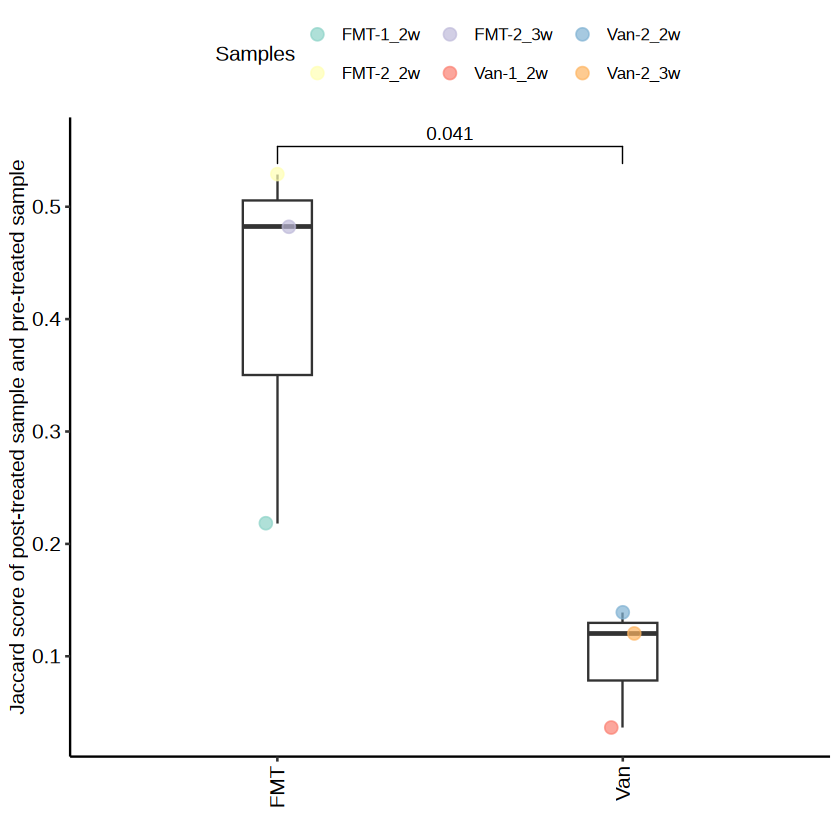

In [140]:
library(tidyplots)
head(jcdf)
p2.2 = ggplot(jcdf,aes(x = group,y = value)) + 
    geom_boxplot(width = 0.2,lwd = 0.5,outlier.shape = NA) +
    geom_point(aes(color = Var2),size = 3,alpha = 0.7,stroke.size = 0.5,position = position_dodge(0.1)) +
    #scale_fill_npg() +
    scale_color_brewer(palette = "Set3") +
    stat_compare_means(paired = TRUE,method = "t.test",comparisons = list(c("FMT","Van"))) + theme_pubr() + 
    xlab("") + ylab("Jaccard score of post-treated sample and pre-treated sample") + labs(color = "Samples") + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p2.2
ggexport(p2.2,filename = "../downstream_analysis/figures/species_treat_change_jaccard_score_25_10_10.pdf",width =5,height = 5.5)

In [47]:
#head(cmpspmx2)

cmpspmx$diff1 = cmpspmx$`2w` - cmpspmx$`1w`
cmpspmx$diff2 = cmpspmx$`3w` - cmpspmx$`1w`
cmpspmx2 = dcast(cmpspmx,species~group,value.var = "diff1")
cmpspmx3 = dcast(cmpspmx[cmpspmx$group %in% c("FMT-2","Van-2"),],species~group,value.var = "diff2")
#cmpspmx3
rownames(cmpspmx2) = cmpspmx2$species;cmpspmx2 = cmpspmx2[,-1]
rownames(cmpspmx3) = cmpspmx3$species;cmpspmx3 = cmpspmx3[,-1]
colnames(cmpspmx3) = c("FMT-2_3W","Van-2_3W")
cmpspmx2 = merge(cmpspmx2,cmpspmx3,by = "row.names",all =TRUE)
rownames(cmpspmx2) = cmpspmx2$Row.names;cmpspmx2 = cmpspmx2[,-1]
head(cmpspmx2)
dim(cmpspmx2)
cmpspmx2[is.na(cmpspmx2)] = 0
cmpspmx2l = melt(cmpspmx2)
cmpspmx2 = cmpspmx2[rowSums(abs(cmpspmx2)) > 0.05,]
dim(cmpspmx2)
library(pheatmap)
cmpspmx2 = cmpspmx2[,c("FMT-1","FMT-2","FMT-2_3W","Van-1","Van-2","Van-2_3W")]

,FMT-1,FMT-2,Van-1,Van-2,FMT-2_3W,Van-2_3W
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
[Clostridium] asparagiforme,NA,0.0004311209,NA,0.0000000000,0.0005870686,0.0001701548
[Clostridium] hylemonae,0.0004710316,0.0002352777,NA,NA,0.0006652731,NA
[Clostridium] innocuum,-0.1035200993,-0.0298099564,-0.10250583,0.1003549153,-0.0321799435,0.0178813328
[Clostridium] scindens,0.0004710316,-0.0026703629,-0.04480398,-0.0005880047,0.0076342482,-0.0005880047
[Eubacterium] eligens,NA,0.0006162162,NA,NA,-0.0050035841,NA
[Ruminococcus] lactaris,NA,-0.0002346133,NA,NA,-0.0002346133,NA


[1] 326   6

No id variables; using all as measure variables



[1] 31  6

In [49]:
graman <- data.frame(
  species = c(
    "Bifidobacterium animalis", "Bifidobacterium breve", "Bifidobacterium bifidum", 
    "Bifidobacterium longum", "Enterococcus casseliflavus", "Bacteroides fragilis", 
    "Bacteroides thetaiotaomicron", "Bacteroides uniformis", "Phocaeicola vulgatus", 
    "Parabacteroides distasonis", "[Clostridium] innocuum", "[Clostridium] scindens", 
    "[Ruminococcus] torques", "Agathobacter rectalis", "Blautia coccoides", 
    "Blautia pseudococcoides", "Eisenbergiella porci", "Blautia", 
    "Mediterraneibacter faecis", "Faecalibacterium prausnitzii", "Faecalibacterium sp.", 
    "Ruminococcus bromii", "Ruthenibacterium lactatiformans", "Mediterraneibacter gnavus", 
    "Roseburia faecis", "Thomasclavelia ramosa", "Klebsiella pneumoniae", 
    "Raoultella planticola", "Escherichia coli", "Veillonella parvula", 
    "Peptonophilus genitalis"
  ),
  Gram_Stain = c(
    "Positive", "Positive", "Positive", "Positive", "Positive", "Negative", 
    "Negative", "Negative", "Negative", "Negative", "Positive", "Positive", 
    "Positive", "Positive", "Positive", "Positive", "Positive", "Positive", 
    "Positive", "Positive", "Positive", "Positive", "Positive", "Positive", 
    "Positive", "Positive", "Negative", "Negative", "Negative", "Negative", 
    "Positive"
  ),
  stringsAsFactors = FALSE
)
cmpspmx2.an = cmpspmx2
cmpspmx2.an$species = rownames(cmpspmx2.an)
cmpspmx2.an = merge(cmpspmx2.an,graman,by = "species")
cmpspmx2.an

species,FMT-1,FMT-2,FMT-2_3W,Van-1,Van-2,Van-2_3W,Gram_Stain
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
[Clostridium] innocuum,-0.1035200993,-2.980996e-02,-3.217994e-02,-0.1025058267,0.1003549153,0.0178813328,Positive
[Clostridium] scindens,0.0004710316,-2.670363e-03,7.634248e-03,-0.0448039826,-0.0005880047,-0.0005880047,Positive
[Ruminococcus] torques,0.1144606689,8.167101e-04,-1.086999e-02,0.0000000000,0.0000000000,0.0000000000,Positive
Agathobacter rectalis,0.0000000000,1.210985e-01,-6.971316e-02,0.0000000000,0.0000000000,0.0013612387,Positive
Bacteroides fragilis,0.1884126236,2.100693e-02,8.567838e-02,-0.0062227754,-0.0631100084,-0.2723086437,Negative
Bacteroides thetaiotaomicron,0.0012189378,1.588124e-03,4.315165e-04,-0.0024891101,0.0874580361,-0.0584084673,Negative
Bacteroides uniformis,-0.0004434590,8.549250e-03,-2.136248e-02,-0.0006222775,-0.0423363387,-0.0401243258,Negative
Bifidobacterium animalis,0.0000000000,0.000000e+00,0.000000e+00,0.0000000000,0.0000000000,0.0682320912,Positive
Bifidobacterium bifidum,0.0000000000,5.881942e-05,-7.820443e-05,0.0000000000,0.0000000000,0.0622766718,Positive


Warning message in brewer.pal(n = 2, name = "Set1"):
"minimal value for n is 3, returning requested palette with 3 different levels
"


Positive  Negative 
"#E41A1C" "#377EB8"

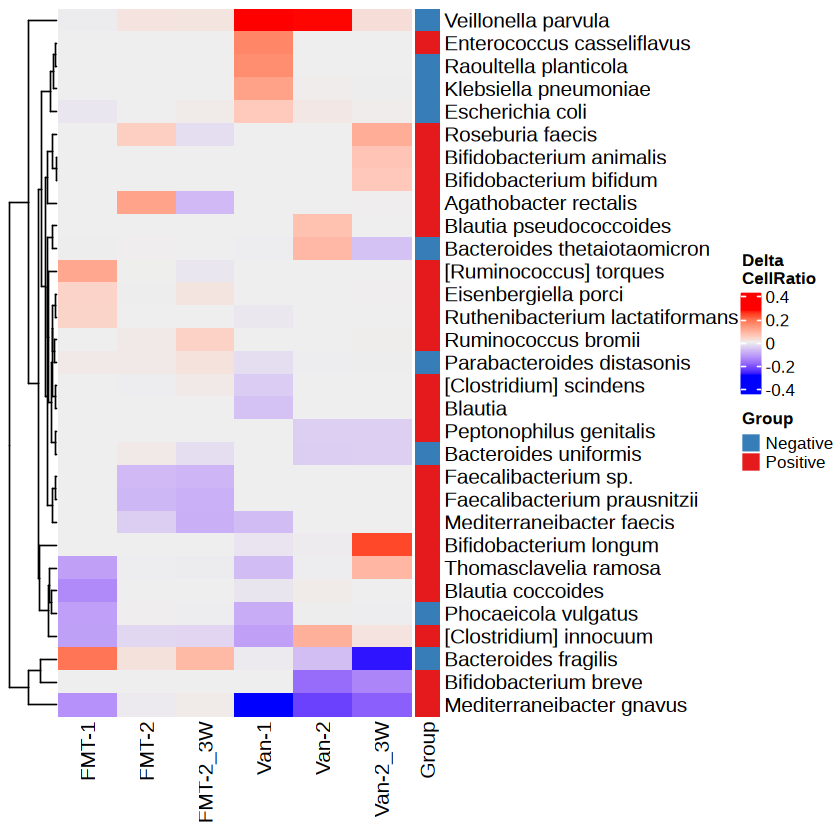

In [52]:
library(RColorBrewer)
library(ComplexHeatmap)
set_colors <- brewer.pal(n = 2, name = "Set1")
#print(set_colors)
cmpspmx2.an = cmpspmx2.an[order(cmpspmx2.an$Gram_Stain),]
group_vector <- setNames(
  cmpspmx2.an$Gram_Stain,
  cmpspmx2.an$species
)
group_colors <- setNames(
  set_colors[1:2],
  c("Positive","Negative")
)
group_colors
row_ha <- rowAnnotation(
  Group = group_vector, # 指定注释数据
  col = list(Group = group_colors) # 指定颜色映射关系
)
cmpspmx2 = cmpspmx2[cmpspmx2.an$species,]
cmpspmx2 = as.matrix(cmpspmx2)
#row_ha
Heatmap(cmpspmx2,cluster_columns = FALSE,cluster_rows = TRUE,name = "Delta\nCellRatio",right_annotation = row_ha)

In [53]:
pdf("../downstream_analysis/figures/species_treatchange_cellratio_0.05_heamap.pdf",width = 7,height = 7)
Heatmap(cmpspmx2,cluster_columns = FALSE,cluster_rows = TRUE,name = "Delta\nCellRatio",right_annotation = row_ha)
dev.off()

pdf 
  2

In [162]:
head(cmpspmx2)
cmpspmx2$species = row.names(cmpspmx2)
nrow(cmpspmx2)
cmpspmx2 = merge(cmpspmx2,tax_df,by = "species")
nrow(cmpspmx2)
pls = list()
library(RColorBrewer)
my_colors <- brewer.pal(length(unique(cmpspmx2$class)), "Paired")
names(my_colors) = unique(cmpspmx2$class)
cmpspmxt = NULL
for(i in 1:6){
    cmpspmxi = cmpspmx2[,c(1,1+i,8,9)]
    cmpspmxi$sample = colnames(cmpspmxi)[2]
    colnames(cmpspmxi)[2] = "delta"
    cmpspmxi = cmpspmxi[abs(cmpspmxi$delta) > 0.05,]
    cmpspmxi = cmpspmxi[order(-cmpspmxi$delta),]
    cmpspmxi$species = factor(cmpspmxi$species,levels = cmpspmxi$species)
    pi = ggplot(cmpspmxi,aes(x = species,y = delta,fill = class)) + geom_bar(stat = "identity",width = 0.4) + 
    theme_pubr() + scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + ggtitle(unique(cmpspmxi$sample)) +
    ylim(c(-0.35,0.35)) + ylab("Delta cell ratio") + xlab("")
    cmpspmxt = rbind(cmpspmxt,cmpspmxi)
    pls[[i]] = pi
}
#pls


,FMT-1,FMT-2,FMT-2_3W,Van-1,Van-2,Van-2_3W
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
[Clostridium] innocuum,-0.1035200993,-0.0298099564,-0.0321799435,-0.102505827,0.1003549153,0.0178813328
[Clostridium] scindens,0.0004710316,-0.0026703629,0.0076342482,-0.044803983,-0.0005880047,-0.0005880047
[Ruminococcus] torques,0.1144606689,0.0008167101,-0.0108699869,0.000000000,0.0000000000,0.0000000000
Agathobacter rectalis,0.0000000000,0.1210985469,-0.0697131574,0.000000000,0.0000000000,0.0013612387
Bacteroides fragilis,0.1884126236,0.0210069327,0.0856783800,-0.006222775,-0.0631100084,-0.2723086437
Bacteroides thetaiotaomicron,0.0012189378,0.0015881242,0.0004315165,-0.002489110,0.0874580361,-0.0584084673


species,order,class
<chr>,<chr>,<chr>
Escherichia coli,Enterobacterales,Gammaproteobacteria
Phocaeicola vulgatus,Bacteroidales,Bacteroidia
Anaerostipes caccae,Lachnospirales,Clostridia
Parabacteroides distasonis,Bacteroidales,Bacteroidia
Mediterraneibacter gnavus,Lachnospirales,Clostridia
Blautia producta,Lachnospirales,Clostridia
Clostridioides difficile,Peptostreptococcales,Clostridia
Prevotella scopos,Bacteroidales,Bacteroidia
Wansuia hejianensis,Lachnospirales,Clostridia


In [204]:
head(cmpspmxt)

species,delta,order,class,sample,group,deltam,sd
<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
Bacteroides fragilis,0.1884126,Bacteroidales,Bacteroidia,FMT-1,FMT,0.1370455,0.07264408
[Ruminococcus] torques,0.1144607,Lachnospirales,Clostridia,FMT-1,FMT,0.1144607,NA
Thomasclavelia ramosa,-0.1030077,Erysipelotrichales,Erysipelotrichia,FMT-1,FMT,-0.1030077,NA
[Clostridium] innocuum,-0.1035201,Clostridiales,Clostridia,FMT-1,FMT,-0.1035201,NA
Phocaeicola vulgatus,-0.1043519,Bacteroidales,Bacteroidia,FMT-1,FMT,-0.1043519,NA
Mediterraneibacter gnavus,-0.1236458,Lachnospirales,Clostridia,FMT-1,FMT,-0.1236458,NA


Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_point()`)."
file saved to ../downstream_analysis/figures/species_treatchange_cellratio_0.05_barplot.pdf



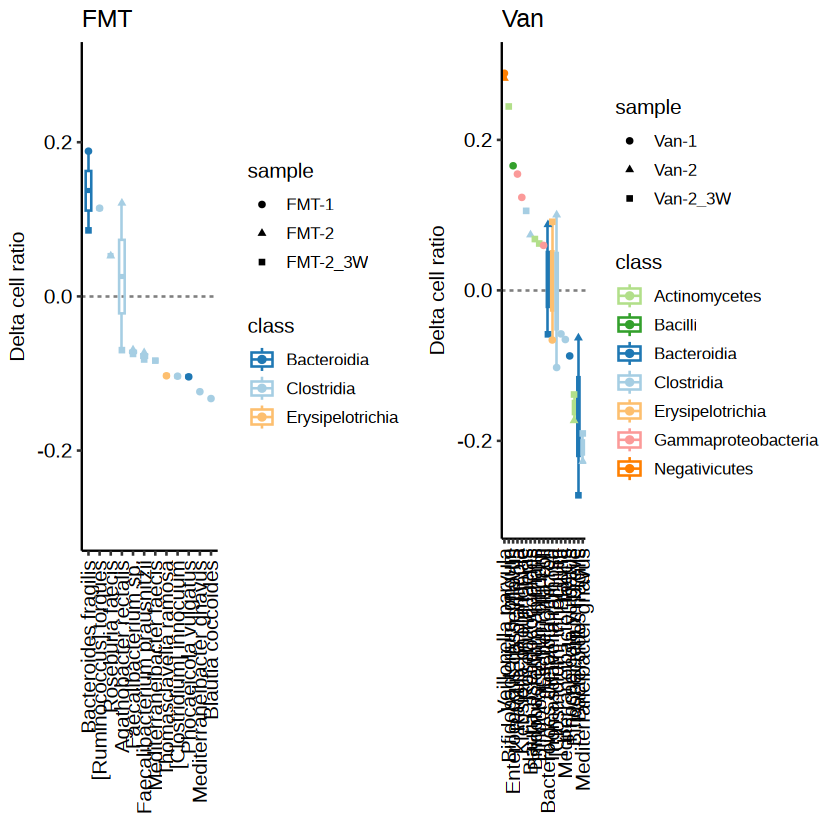

In [223]:
cmpspmxt = cmpspmxt %>% group_by(group,species,class) %>% mutate(deltam = mean(delta),sd = sd(delta))
#cmpspmxt.st
#cmpspmxt = cmpspmxt[!is.na(cmpspmxt$sd),]
cmpspmxt.st.fmt = cmpspmxt[cmpspmxt$group == "FMT",]
#cmpspmxt.st.fmt
cmpspmxt.st.fmt = cmpspmxt.st.fmt[order(-cmpspmxt.st.fmt$deltam),]
cmpspmxt.st.fmt$species = factor(cmpspmxt.st.fmt$species,levels = unique(cmpspmxt.st.fmt$species))
pi1 = ggplot(cmpspmxt.st.fmt,aes(x = species,y = delta,fill = class,color = class)) +
    geom_hline(yintercept = 0,linetype = 2,alpha = 0.5) +
    #geom_bar(width = 0.05,stat = "identity") + 
    geom_boxplot(fill = NA,width = 0.5) +
    geom_point(aes(shape = sample),size = 1.5) + 
    
    theme_pubr() + scale_color_manual(values = my_colors) +
    scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + 
    ylim(c(-0.3,0.3)) + ylab("Delta cell ratio") + xlab("") + ggtitle("FMT")

cmpspmxt.st.van = cmpspmxt[cmpspmxt$group != "FMT",]
#cmpspmxt.st.fmt
cmpspmxt.st.van = cmpspmxt.st.van[order(-cmpspmxt.st.van$deltam),]
cmpspmxt.st.van$species = factor(cmpspmxt.st.van$species,levels = unique(cmpspmxt.st.van$species))
pi2 = ggplot(cmpspmxt.st.van,aes(x = species,y = delta,fill = class,color = class)) +
    geom_hline(yintercept = 0,linetype = 2,alpha = 0.5) +
    geom_boxplot(fill = NA,width = 0.5,outlier.stroke = 0.5) +
    #geom_bar(width = 0.05,stat = "identity") + 
    geom_point(aes(shape = sample),size = 1.5) + 
    theme_pubr() + scale_color_manual(values = my_colors) +
    scale_fill_manual(values = my_colors) +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + 
    ylim(c(-0.3,0.3)) + ylab("Delta cell ratio") + xlab("") + ggtitle("Van")
pt = ggarrange(pi1,pi2,legend = "right")
pt
ggexport(pt,filename = "../downstream_analysis/figures/species_treatchange_cellratio_0.05_barplot.pdf",width = 12,height = 7)


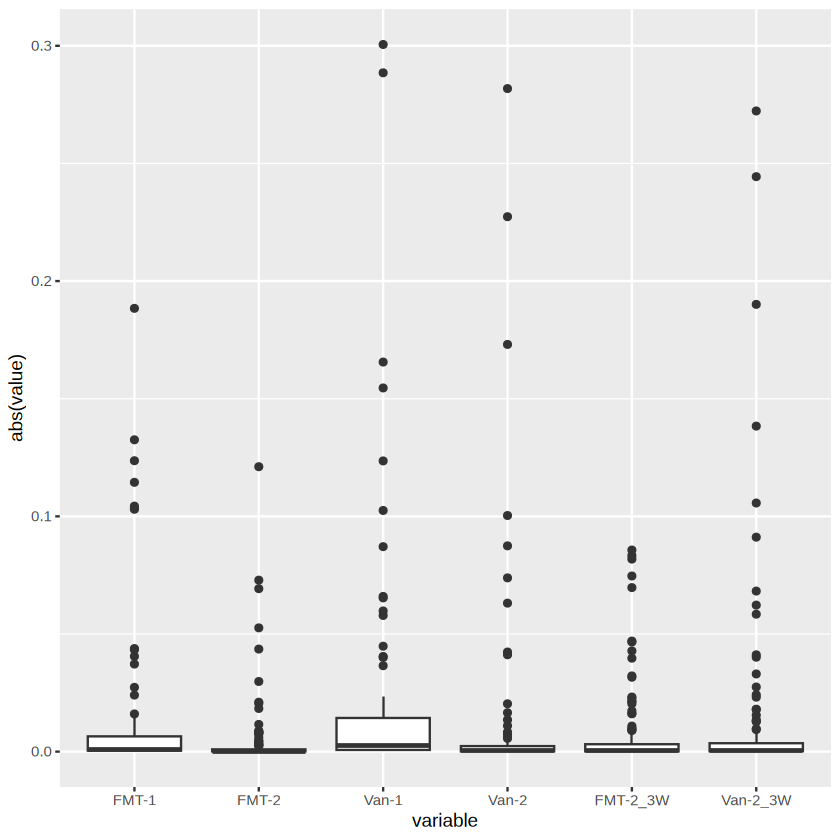

In [88]:
#head(cmpspmx2l)
ggplot(cmpspmx2l[cmpspmx2l$value != 0,],aes(x = variable,y = abs(value))) + geom_boxplot()

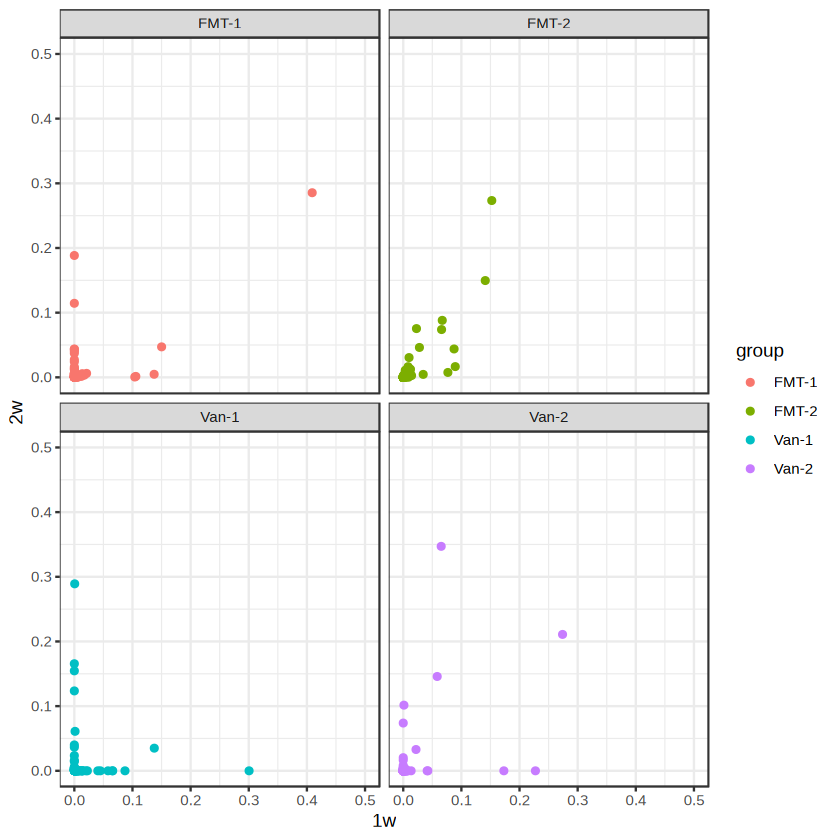

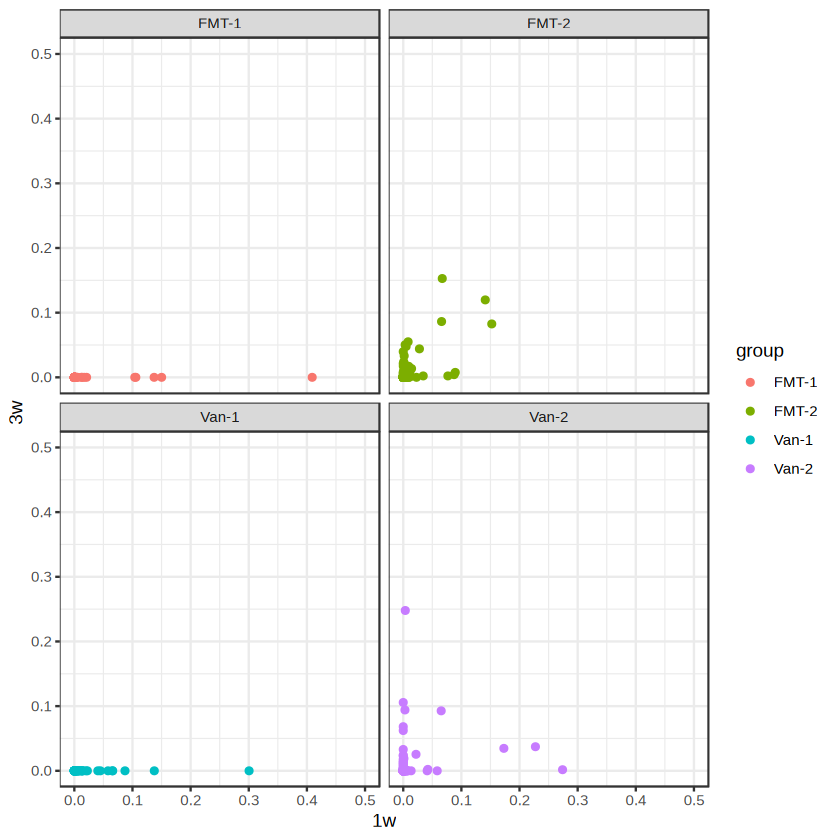

In [31]:
ggplot(cmpspmx,aes(x = `1w`,y = `2w`,color = group)) + geom_point() + theme_bw() + xlim(c(0,0.5)) + ylim(c(0,0.5)) +
        facet_wrap(~group)
ggplot(cmpspmx,aes(x = `1w`,y = `3w`,color = group)) + geom_point() + theme_bw() + xlim(c(0,0.5)) + ylim(c(0,0.5)) +
        facet_wrap(~group)

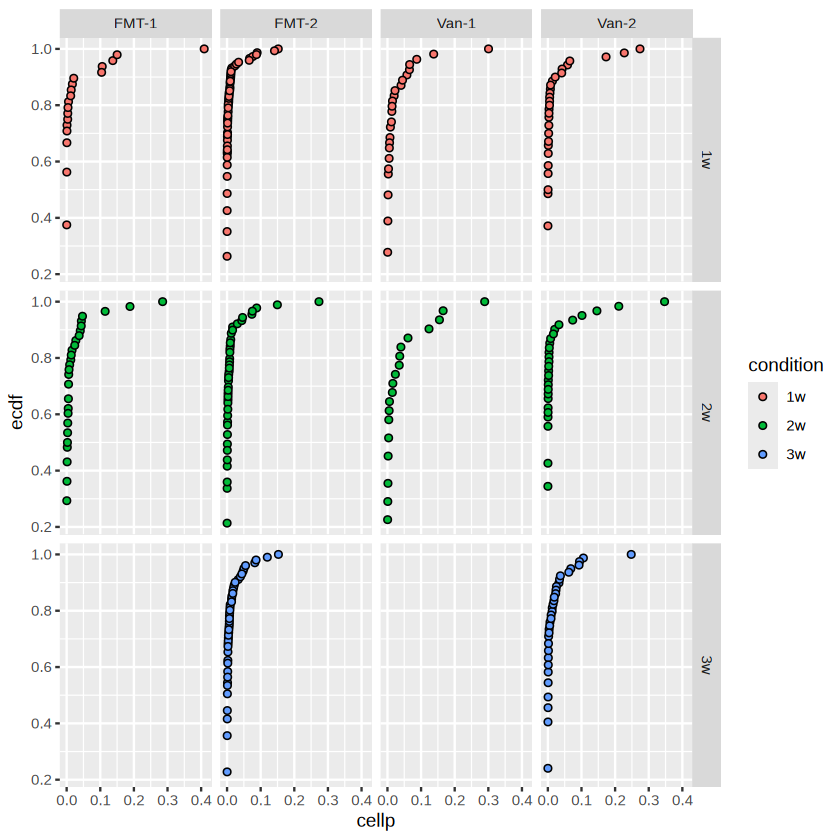

In [32]:
library(ggplot2)
library(dplyr)

cmpsp %>%
  #slice_sample(prop = 0.01) %>%
  ggplot(aes(x = cellp, fill = condition)) +
  stat_ecdf(geom = 'point', pad = F, shape = 21) +
  facet_grid(condition~group)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


group,condition,shannon,simpson,Pielou_Evenness
<chr>,<chr>,<dbl>,<dbl>,<dbl>
FMT-1,1w,1.854352,4.312887,0.4790120
FMT-1,2w,2.555185,7.066182,0.6292873
FMT-2,1w,3.095752,12.875593,0.6194958
FMT-2,2w,2.746679,8.143194,0.6119185
FMT-2,3w,3.197471,14.780031,0.6928250
Van-1,1w,2.605438,7.425717,0.6531584
Van-1,2w,2.195261,6.280325,0.6392747
Van-2,1w,2.234521,5.921416,0.5259558
Van-2,2w,1.971159,4.903338,0.4794989


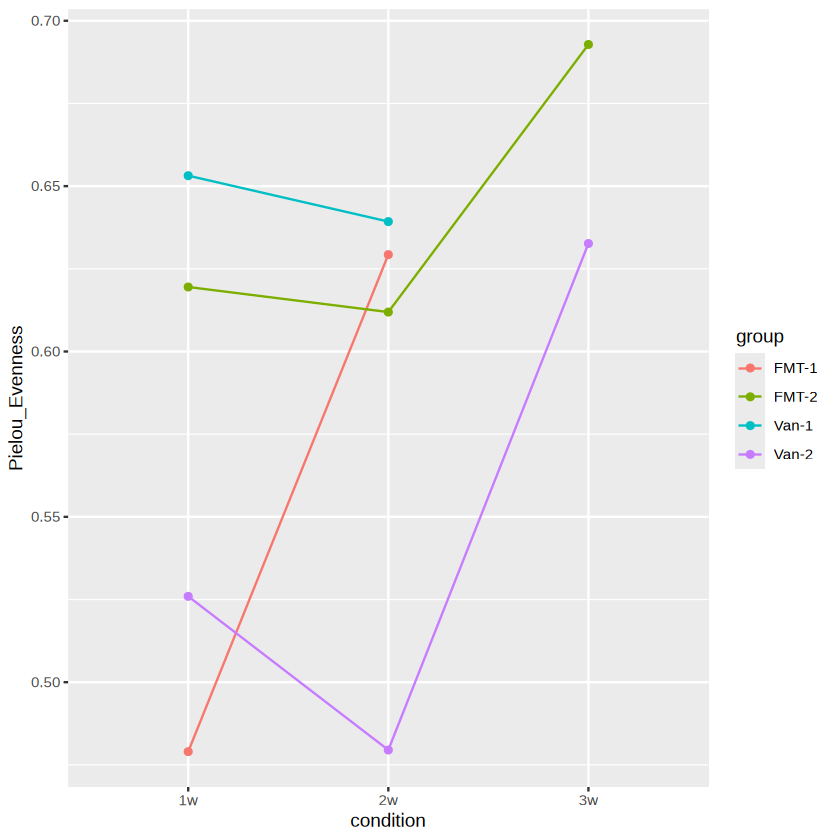

In [71]:
#shannon
library(vegan)
cmpsp.st = cmpsp %>% group_by(group,condition) %>% summarise(shannon = diversity(cellp, index = "shannon"),
                                                              simpson = diversity(cellp, index = "invsimpson"),
                                                            Pielou_Evenness = shannon / log(length(cellp > 0)))
cmpsp.st

ggplot(cmpsp.st,aes(x = condition,y = Pielou_Evenness,color = group, group = group)) + geom_point() + geom_line()

In [234]:
results = NULL
for (row in 1:nrow(cmpspmx)) {
    before <- unlist(cmpspmx[row, c(1,3,5,7)])  
    after <- unlist(cmpspmx[row, c(2,4,6,8)])
    test <- t.test(before, after,paired = T)
    diff = mean(after) - mean(before)
    mafter = mean(after)
    mbefore = mean(before)
    # 记录结果
    results = rbind(results,data.frame(
      Species = rownames(cmpspmx)[row],
      Mbefore = mbefore,
      Mafter = mafter,
      diff = diff,
      P_Value = test$p.value
    ))
}
results = results[!is.nan(results$P_Value),]
results$padj = p.adjust(results$P_Value)
results  
results[results$P_Value < 0.05,]

,Species,Mbefore,Mafter,diff,P_Value,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,[Clostridium] asparagiforme,9.771732e-05,0.0002868702,1.891529e-04,0.2650582,1
2,[Clostridium] hylemonae,7.817386e-05,0.0003619232,2.837494e-04,0.1908798,1
3,[Clostridium] innocuum,6.925220e-02,0.0141694566,-5.508274e-02,0.1587290,1
4,[Clostridium] scindens,1.369321e-02,0.0043689600,-9.324253e-03,0.4926780,1
5,[Eubacterium] eligens,1.934803e-03,0.0006841282,-1.250675e-03,0.3910022,1
6,[Ruminococcus] lactaris,5.863039e-05,0.0000000000,-5.863039e-05,0.3910022,1
7,[Ruminococcus] torques,2.911976e-03,0.0287702535,2.585828e-02,0.4465187,1
8,Abiotrophia defectiva,1.954346e-05,0.0001701548,1.506114e-04,0.4587812,1
9,Acetatifactor acetigignens,0.000000e+00,0.0053264269,5.326427e-03,0.3910022,1


Species,Mbefore,Mafter,diff,P_Value,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

Warning message in aldex.clr.function(reads, conds, mc.samples, denom, verbose, :
"values are unreliable when estimated with so few MC smps"
computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes



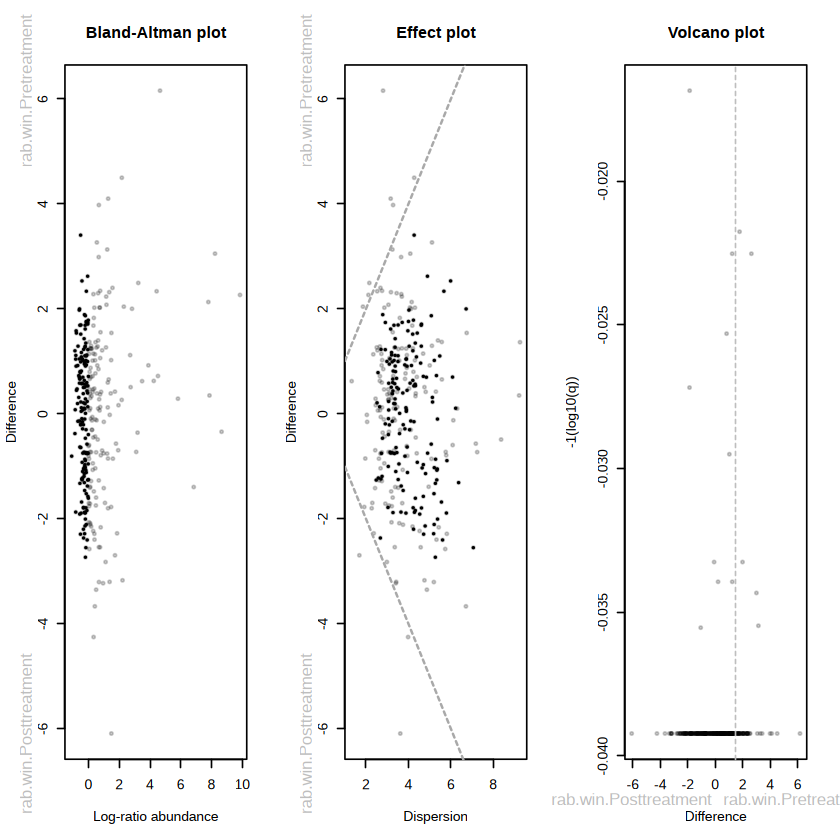

In [178]:
#BiocManager::install("ALDEx2")
library(ALDEx2)

x.aldex <- aldex(cmpspmx, conds, mc.samples=16, test="t", effect=TRUE, 
  include.sample.summary=FALSE, denom="all", verbose=FALSE, paired.test=TRUE, gamma=NULL)

par(mfrow=c(1,3))
aldex.plot(x.aldex, type="MA", test="welch", xlab="Log-ratio abundance",
    ylab="Difference", main='Bland-Altman plot')
aldex.plot(x.aldex, type="MW", test="welch", xlab="Dispersion",
    ylab="Difference", main='Effect plot')
aldex.plot(x.aldex, type="volcano", test="welch", xlab="Difference",
    ylab="-1(log10(q))", main='Volcano plot')

In [180]:
x.aldex[x.aldex$wi.ep < 0.05,]
cmpspmx[rownames(cmpspmx) %in% rownames(x.aldex[x.aldex$wi.ep < 0.05,]),]

,rab.all,rab.win.Posttreatment,rab.win.Pretreatment,diff.btw,diff.win,effect,overlap,we.ep,we.eBH,wi.ep,wi.eBH
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phocaeicola vulgatus,4.648677,1.773734,7.233693,6.157925,2.804064,2.196071,0.002188379,0.02184092,1,0.03214286,1


,A1,A2,B1,B2,C282_1,C282_3,C295_1,C295_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phocaeicola vulgatus,477,3,140,0,10,0,44,2


#### Total summary

In [28]:
tdf = read.csv("../data/total_information_06_23.csv")
tdf$group = 1
tdf.st = tdf %>% group_by(group) %>% summarise(pBI143_ratio = length(copy_number[!is.na(copy_number)])/nrow(tdf),
                          crass_ratio = length(ref[!is.na(ref)])/nrow(tdf),
                          van_ratio = length(gene[!is.na(gene)])/nrow(tdf))
tdf.st

group,pBI143_ratio,crass_ratio,van_ratio
<dbl>,<dbl>,<dbl>,<dbl>
1,0.3031847,0.01014036,0.01433218


In [29]:
tdf.st = tdf %>% group_by(species) %>% summarise(pBI143_ratio = length(copy_number[!is.na(copy_number)])/n(),
                          crass_ratio = length(ref[!is.na(ref)])/n(),
                          van_ratio = length(gene[!is.na(gene)])/n())
tdf.st[order(-tdf.st$pBI143_ratio),]

species,pBI143_ratio,crass_ratio,van_ratio
<chr>,<dbl>,<dbl>,<dbl>
Lancefieldella sp000564995,0.9166667,0.000000000,0.000000000
Anaerococcus murdochii,0.8947368,0.000000000,0.000000000
Bacteroides thetaiotaomicron,0.7088689,0.001928021,0.000000000
Bacteroides fragilis,0.7015891,0.076496674,0.002402069
Lachnoclostridium phytofermentans,0.6857143,0.000000000,0.000000000
Clostridium tertium,0.6818182,0.022727273,0.113636364
Enterococcus lactis,0.6811594,0.000000000,0.000000000
Bacteroides uniformis,0.6756757,0.008830613,0.001337972
Lachnospira pectinoschiza,0.6666667,0.047619048,0.000000000


In [30]:
cor(tdf.st$pBI143_ratio,tdf.st$crass_ratio)
tdf.st[order(-tdf.st$crass_ratio),]

[1] 0.003248033

species,pBI143_ratio,crass_ratio,van_ratio
<chr>,<dbl>,<dbl>,<dbl>
,0.0000000,1.000000000,1.0000000000
Paraprevotella clara,0.0000000,0.250000000,0.0000000000
Bacteroides fragilis,0.7015891,0.076496674,0.0024020695
Alistipes onderdonkii,0.5873016,0.063492063,0.0000000000
Alistipes finegoldii,0.0000000,0.058823529,0.0000000000
Lachnospira pectinoschiza,0.6666667,0.047619048,0.0000000000
MAG: Alistipes,0.0000000,0.047619048,0.0476190476
Clostridium tertium,0.6818182,0.022727273,0.1136363636
Parabacteroides goldsteinii,0.6000000,0.022222222,0.0000000000


#### f1 celltype diversity

In [7]:
head(anidf)

,name,species,GCA,ANI,db,sample,group,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CAAGAAA_CGTAGCA_ACGATAC,Escherichia coli,GCF_027945035.1,100,refseq,A1,A,Pretreatment
2,CCTACAC_TTAGGAC_AACTCTT,Escherichia coli,GCF_905330275.2,100,refseq,A1,A,Pretreatment
3,GCTCTGT_GATCGTA_TCGTAGA,Phocaeicola vulgatus,GCF_024022975.1,100,refseq,A1,A,Pretreatment
4,CGGAGCT_ACCAAGT_AAATGAG,Phocaeicola vulgatus,GCF_024758205.1,100,refseq,A1,A,Pretreatment
5,AACCGCG_CATATCG_CGATTAT,Phocaeicola vulgatus,GCF_008728395.1,100,refseq,A1,A,Pretreatment
6,AAGACCT_ACGCAGA_TTGCCGT,Anaerostipes caccae,GCF_014131675.1,100,refseq,A1,A,Pretreatment


In [150]:
gcadf = as.data.frame(unique(celldivdf[,'GCA']))
write.table(gcadf,file = "../data/GCA_refile.txt",row.names = F,col.names = F,quote =F)

In [76]:
#sample cell number and species stat
cellstat.st = celldivdf %>% group_by(sample) %>% summarise(cellnumt = length(unique(new_name)),speciesnum = length(unique(species)))
cellstat.st$group = MySplit(cellstat.st$sample,"_",1)
cellstat.st$condition = MySplit(cellstat.st$sample,"_",2)
cellstat.st[cellstat.st$group == "C282",]$group = "Vancomycin"
cellstat.st[cellstat.st$group == "C295",]$group = "FMT"
cellstat.st$diversity = cellstat.st$speciesnum/cellstat.st$cellnumt
p1.1 = ggplot(cellstat.st,
       aes(x = condition, y = cellnumt,fill = group)) + 
        geom_col(position = position_dodge2(0.9,preserve = "single"),width = 0.5) +
        scale_fill_npg() + ylab("Number of cells") +
        theme_pubr()
p1.2 = ggplot(cellstat.st,
       aes(x = condition, y = speciesnum,fill = group)) + 
        geom_col(position = position_dodge2(0.9,preserve = "single"),width = 0.5) +
        scale_fill_npg() + ylab("Number of species") +
        theme_pubr()
# ggplot(cellstat.st,
#        aes(x = condition, y = diversity,fill = group)) + 
#         geom_col(position = position_dodge2(0.9,preserve = "single"),width = 0.5) +
#         scale_fill_npg() +
#         theme_pubr()
library(ggpubr)
ggexport(ggarrange(p1.1,p1.2,nrow = 1,common.legend = T), 
         filename = "../downstream_analysis/figures/f1.0_datastat_sample_celln_speciesn_25_08_18.pdf",
         width = 5,height = 4)

file saved to ../downstream_analysis/figures/f1.0_datastat_sample_celln_speciesn_25_06_14.pdf



In [20]:
#celldivdf = read.delim("all_ani_class.txt")
anidf[anidf$sample %in% c("B2","B1"),]$group = "Vancomycin2"
anidf[anidf$sample %in% c("A1","A2"),]$group = "FMT2"
anidf[anidf$sample %in% c("A1","B1"),]$condition = "Pretreatment"
anidf[anidf$sample %in% c("A2","B2"),]$condition = "Posttreatment"

`summarise()` has grouped output by 'group', 'species', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'new_group', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'species', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'new_group', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'species', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'new_group', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'species', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'group', 'new_group', 'condition'. You can
override using the `.groups` argument.


$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

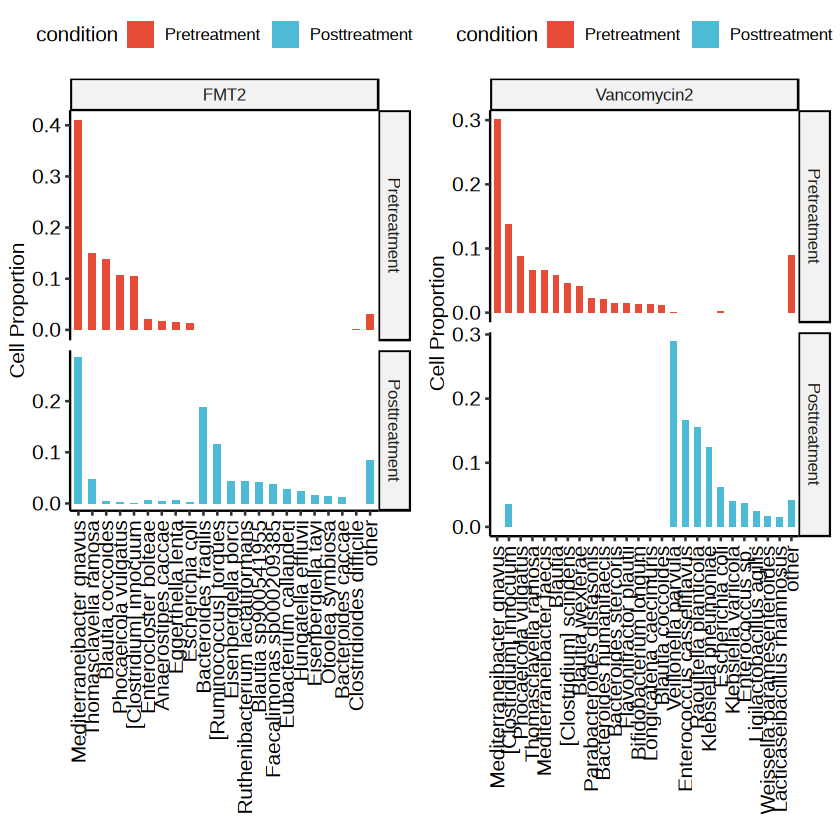

file saved to ../downstream_analysis/figures/f1.0_datastat_species_density_facet_25_08_28.pdf



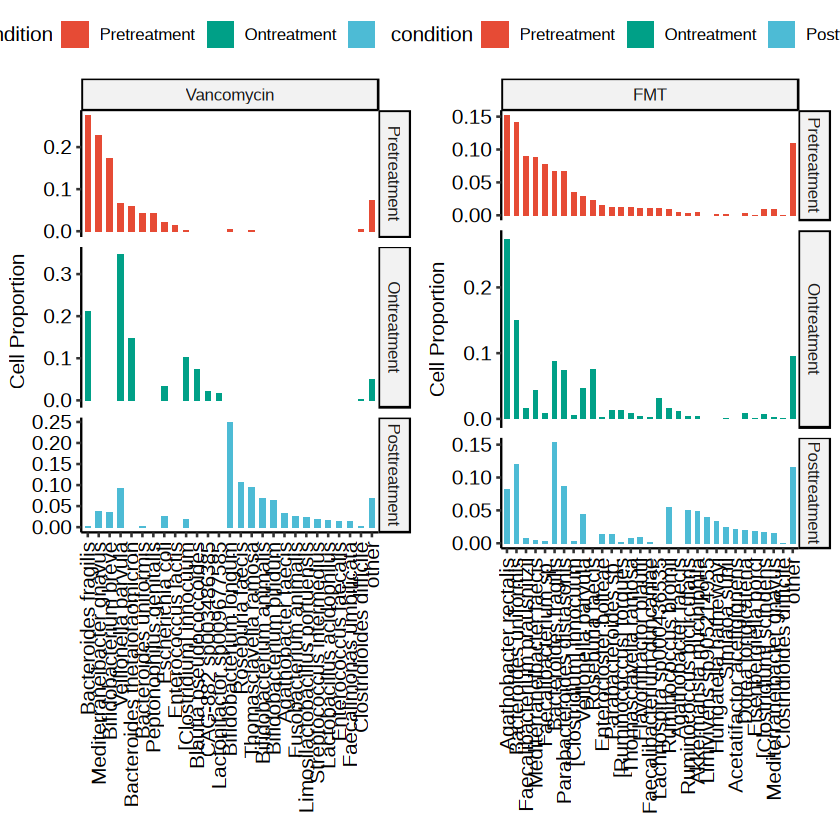

In [42]:
#Total species stat
pls = list()
groupid = unique(anidf$group)
for(i in 1:length(groupid)){
    species.st = anidf[anidf$group == groupid[i],] %>% group_by(group,species,condition,sample) %>% 
              summarise(cellnum = length(unique(name))) %>% 
              group_by(sample) %>% mutate(cellnumt = sum(cellnum),cellnump = cellnum/cellnumt)
    species.st.top = species.st[species.st$cellnump > 0.01,]
    # species.st.top = species.st[species.st$species != "unclassfied",] %>% group_by(group,condition,sample) %>% 
    #                  top_n(n = 30,cellnump)
    species.st.top = species.st.top[order(species.st.top$sample,-species.st.top$cellnump),]
    hubid = unique(c(species.st.top$species,"Clostridioides difficile","unclassfied"))
    species.st$new_group = species.st$species
    species.st[!species.st$species %in% hubid,]$new_group = "other"
    species.st = species.st %>% group_by(group,new_group,condition,sample) %>% 
              summarise(cellnum = sum(cellnum),cellnump = sum(cellnump))
    
    hubid = c(hubid,"other")
    species.st$new_group = factor(species.st$new_group,levels = hubid)
    species.st$condition = factor(species.st$condition, levels = c("Pretreatment","Ontreatment","Posttreatment"))
    mycolor = c('#E64B35','#4DBBD5','#00A087')
    names(mycolor) = c("Pretreatment","Posttreatment","Ontreatment")
    pls[[i]] = ggplot(species.st,
           aes(x = new_group, y = cellnump,fill = condition)) +  
           geom_bar(stat = "identity",position = "dodge",width = 0.5) +
           facet_grid(condition~group,space = "free",scales = "free") +
           scale_fill_manual(values = mycolor) +
           theme_pubr() +
           theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("") + 
           ylab("Cell Proportion")
           #ggtitle("Cell number of top 20 species and Clostridioides difficile")
}
pt = ggarrange(plotlist = pls,ncol = 2)
pt
ggexport(pt, 
         filename = "../downstream_analysis/figures/f1.0_datastat_species_density_facet_25_08_28.pdf",
         width = 10,height = 8)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <8b>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '​​Pretreatment​' in 'mbcsToSbcs': dot substituted for <8b>"
Warn

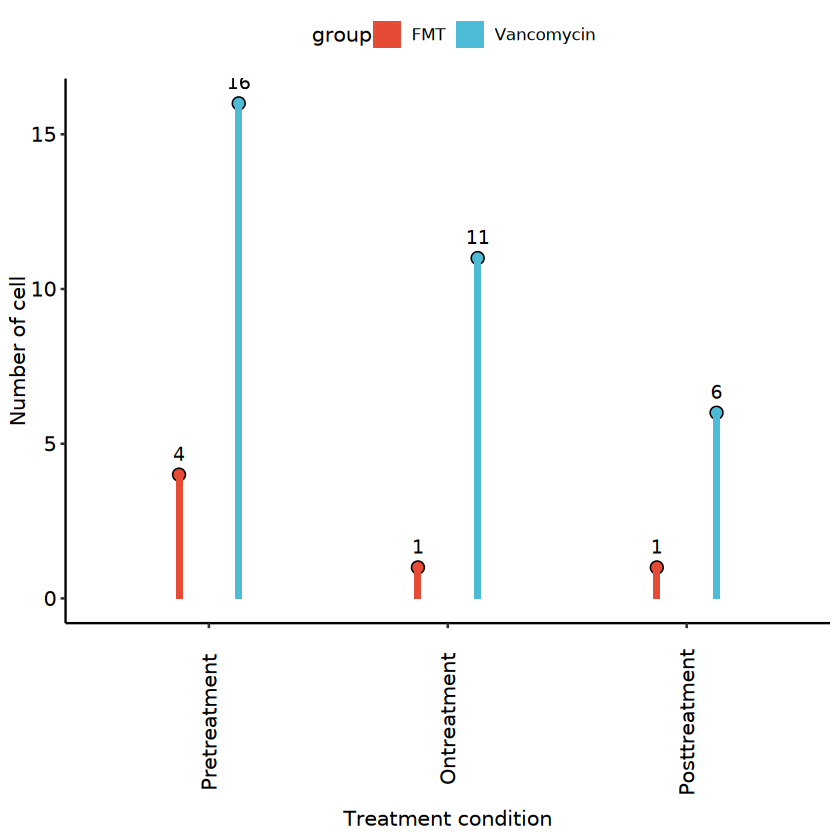

In [9]:
p1.4 = ggplot(data = celldivdf.st.hub,aes(x = condition,y = cellnum,fill = group))+ 
    geom_point(position = position_dodge(0.5),shape = 21,size = 3) + 
    geom_bar(position = position_dodge(0.5),stat = "identity",width = 0.05) +
    geom_text(position = position_dodge(0.5),aes(label=cellnum),vjust = -1) + 
    scale_fill_npg() +
    scale_color_npg() +
    theme_pubr() + theme(axis.text.x = element_text(angle = 90,hjust = 0.5,vjust = 0.5)) + 
xlab("Treatment condition") + ylab("Number of cell")
p1.4
ggexport(p1.4, 
         filename = "../downstream_analysis/figures/f1.1_Clostridioides_difficile_cellnum_25_06_14.pdf",
         width = 2,height = 4)

## Figure6a-c

In [224]:
##load data
pbidf = read.delim("up10_all_pBI143_copy_number.txt",header = T)
pbidf$sample = pbidf$group
length(unique(pbidf$new_name))
length(unique(pbidf$new_name))
#length(unique(celldivdf$new_name))
pbidf$group = MySplit(pbidf$sample,"_",1)
pbidf$condition = MySplit(pbidf$sample,"_",2)
pbidf[pbidf$group == "C282",]$group = "Vancomycin"
pbidf[pbidf$group == "C295",]$group = "FMT"

[1] 17406

[1] 17406

file saved to ../downstream_analysis/figures/f2.1_pBI143_ratio_boxplot_total_25_06_14.pdf



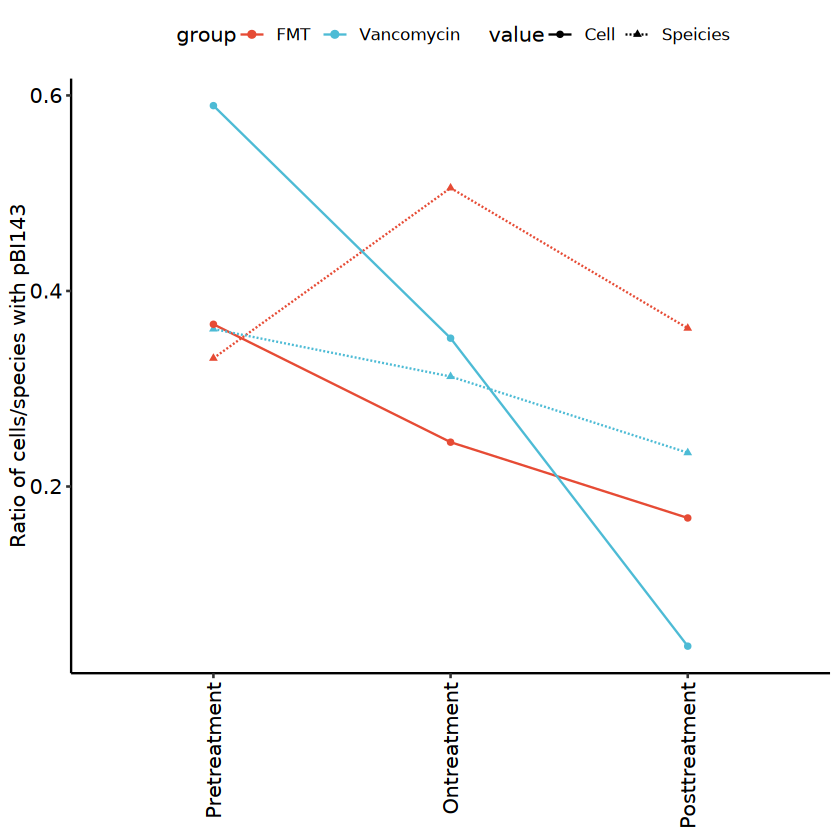

In [217]:
pbidf.st$group2 = paste0(pbidf.st$group,"_",pbidf.st$value)
pbidf.st[pbidf.st$condition == "1",]$condition = "Pretreatment"
pbidf.st[pbidf.st$condition == "2",]$condition = "Ontreatment"
pbidf.st[pbidf.st$condition == "3",]$condition = "Posttreatment"
pbidf.st$condition = factor(pbidf.st$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p2.1 = ggplot(pbidf.st, aes(x = condition, y = pBI143_ratio)) +
  geom_line(aes(color = group, group = group2,linetype = value))+
  geom_point(aes(color = group, group = group2,shape = value)) +
  scale_fill_npg() +
  scale_color_npg() +
  xlab("") + ylab("Ratio of cells/species with pBI143") + theme_pubr() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p2.1
ggexport(p2.1, 
         filename = "../downstream_analysis/figures/f2.1_pBI143_ratio_boxplot_total_25_06_14.pdf",
         width = 3,height = 4)

`summarise()` has grouped output by 'sample', 'group', 'condition'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'sample', 'group', 'condition'. You can
override using the `.groups` argument.


[1] 129

[1] 28

Warning message in geom_point(aes(group = species, fill = group), size = 1.5, shape = 21, :
"Ignoring unknown parameters: `stroke.size`"
file saved to ../downstream_analysis/figures/f2.2_pBI143_ratio_boxplot_of_species_25_06_14.pdf



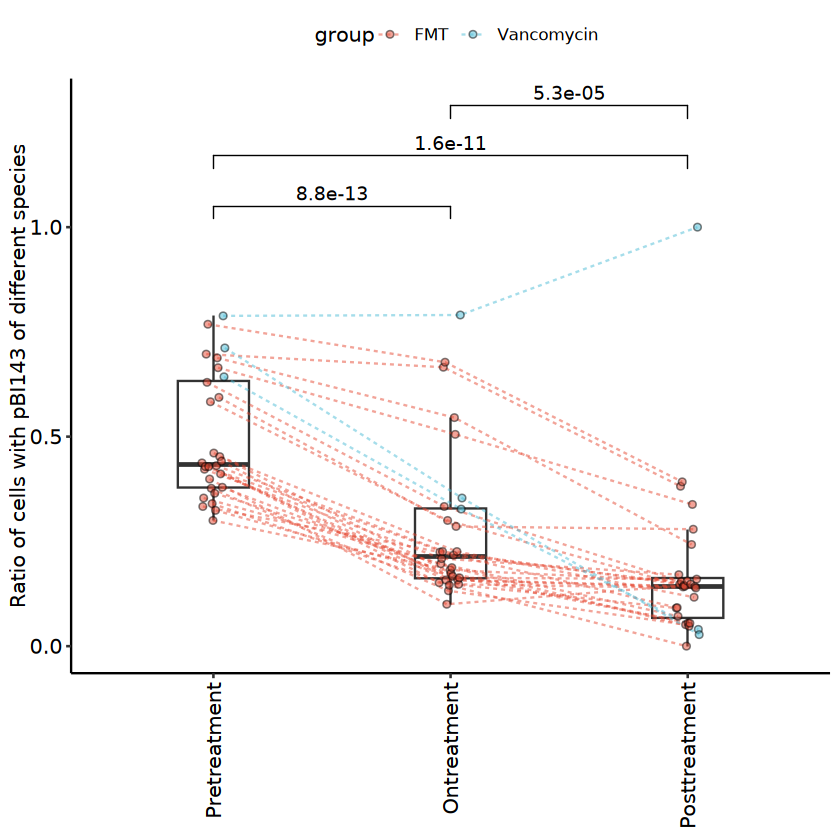

In [221]:
#try digger the reason
samplest.sp = anotdf %>% group_by(sample,group,condition,species) %>% dplyr::summarise(cellnumt = length(unique(new_name)))
pbidf.sp = pbidf %>% dplyr::group_by(sample,group,condition,species) %>% dplyr::summarise(cellnum = length(unique(new_name)))
pbidf.sp = merge(pbidf.sp,samplest.sp,by = c("group","condition","sample","species"),all = TRUE)
pbidf.sp[is.na(pbidf.sp$cellnum),]$cellnum = 0
pbidf.sp$pBI143_ratio = pbidf.sp$cellnum/pbidf.sp$cellnumt
pbidf.sp$species = paste0(pbidf.sp$group,"_",pbidf.sp$species)
pbidf.sp = pbidf.sp[pbidf.sp$cellnumt >= 10,]
pbidf.sp.paired = pbidf.sp %>% group_by(species) %>% filter(length(condition) == 3 & length(condition[cellnum > 0]) > 0)

#nrow(pbidf.sp)
length(unique((pbidf.sp$species)))
length(unique((pbidf.sp.paired$species)))
#pbidf.sp.paired$condition = factor(pbidf.sp.paired$condition)
pbidf.sp.paired[pbidf.sp.paired$condition == "1",]$condition = "Pretreatment"
pbidf.sp.paired[pbidf.sp.paired$condition == "2",]$condition = "Ontreatment"
pbidf.sp.paired[pbidf.sp.paired$condition == "3",]$condition = "Posttreatment"
pbidf.sp.paired$condition = factor(pbidf.sp.paired$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
my_comparisons = list(c("Pretreatment","Ontreatment"),c("Pretreatment","Posttreatment"),c("Ontreatment","Posttreatment"))
p2.2 = ggplot(pbidf.sp.paired,aes(x = condition,y = pBI143_ratio)) + 
    geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA) +
    geom_line(aes(group = species,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    geom_point(aes(group = species,fill = group),size = 1.5,shape = 21,alpha = 0.5,stroke.size = 0.5,position = position_dodge(0.1)) +
    scale_fill_npg() +
    scale_color_npg() +
    # scale_fill_manual(values=c("#993365","#666632"))+
    # scale_color_manual(values=c("#993365","#666632"))+
    # scale_fill_brewer(palette='Set3') +
    # scale_color_brewer(palette='Set3') +
    stat_compare_means(paired = TRUE,method = "t.test",comparisons = my_comparisons) + theme_pubr() + 
    xlab("") + ylab("Ratio of cells with pBI143 of different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p2.2
ggexport(p2.2, 
         filename = "../downstream_analysis/figures/f2.2_pBI143_ratio_boxplot_of_species_25_06_14.pdf",
         width = 3.5,height = 5)

In [5]:
pbidf.filter = pbidf[pbidf$condition %in% c("1","2"),] %>% group_by(group,species) %>% 
                        filter(length(unique(condition)) == 2) 
pbidf.filter = pbidf.filter %>% group_by(group,species) %>% 
               filter(length(new_name[condition == "1"]) > 5 & length(new_name[condition == "2"]) > 5)
pbidf.test1 = pbidf.filter %>% group_by(group,species) %>% 
                dplyr::summarise("premean" = mean(copy_number[condition == "1"]),
                                 "postmean" = mean(copy_number[condition %in% c("2","3")]),
                                 "logfoldchange" = log2(postmean/premean),
                                 pvalue = t.test(copy_number[condition == "1"],copy_number[condition == "2"])$p.value)

pbidf.filter = pbidf[pbidf$condition %in% c("1","3"),] %>% group_by(group,species) %>% 
                        filter(length(unique(condition)) == 2) 
pbidf.filter = pbidf.filter %>% group_by(group,species) %>% 
               filter(length(new_name[condition == "1"]) > 5 & length(new_name[condition == "3"]) > 5)
pbidf.test2 =  pbidf.filter %>% group_by(group,species) %>% 
                dplyr::summarise("premean" = mean(copy_number[condition == "1"]),
                                 "postmean" = mean(copy_number[condition == "3"]),
                                 "logfoldchange" = log2(postmean/premean),
                                 pvalue = t.test(copy_number[condition == "1"],copy_number[condition == "3"])$p.value)
pbidf.test1$padj = p.adjust(pbidf.test1$pvalue)
pbidf.test2$padj = p.adjust(pbidf.test2$pvalue)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


In [6]:
colors <- c("up"="#f07167","down"="#0081a7","none"="#474747")
samplecolors <- c("FMT"="#fe8264","Vancomycin"="#b5dbe6")
pbidf.test1$pair = "PrevsPost2"
pbidf.test2$pair = "PrevsPost4"
pbidf.test = rbind(pbidf.test1,pbidf.test2)
# 看一眼数据
pbidf.test$change = "none"
pbidf.test[pbidf.test$logfoldchange > 1 & pbidf.test$pvalue < 0.05,]$change = "up"
pbidf.test[pbidf.test$logfoldchange < -1  & pbidf.test$pvalue < 0.05,]$change = "down"
library(ggrepel)

Warning message:
"package 'ggrepel' was built under R version 4.3.3"


In [72]:
head(pbidf.test)
nrow(pbidf.test)
length(unique(pbidf.test$species))

group,species,premean,postmean,logfoldchange,pvalue,padj,pair,change
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
FMT,Agathobacter faecis,0.4564058,0.3199325,-0.51254953,0.08304649,1,PrevsPost2,none
FMT,Agathobacter rectalis,1.5434104,2.2683561,0.55552538,0.44855931,1,PrevsPost2,none
FMT,Akkermansia muciniphila,0.4942810,1.0423279,1.07640578,0.43008276,1,PrevsPost2,none
FMT,Bacteroides fragilis,47.6644035,45.8142807,-0.05711487,0.84425087,1,PrevsPost2,none
FMT,Bacteroides thetaiotaomicron,4714.0271369,57.9007641,-6.34723387,0.18528408,1,PrevsPost2,none
FMT,Bacteroides uniformis,152.5549378,93.9876974,-0.69878505,0.15611450,1,PrevsPost2,none


[1] 55

[1] 35

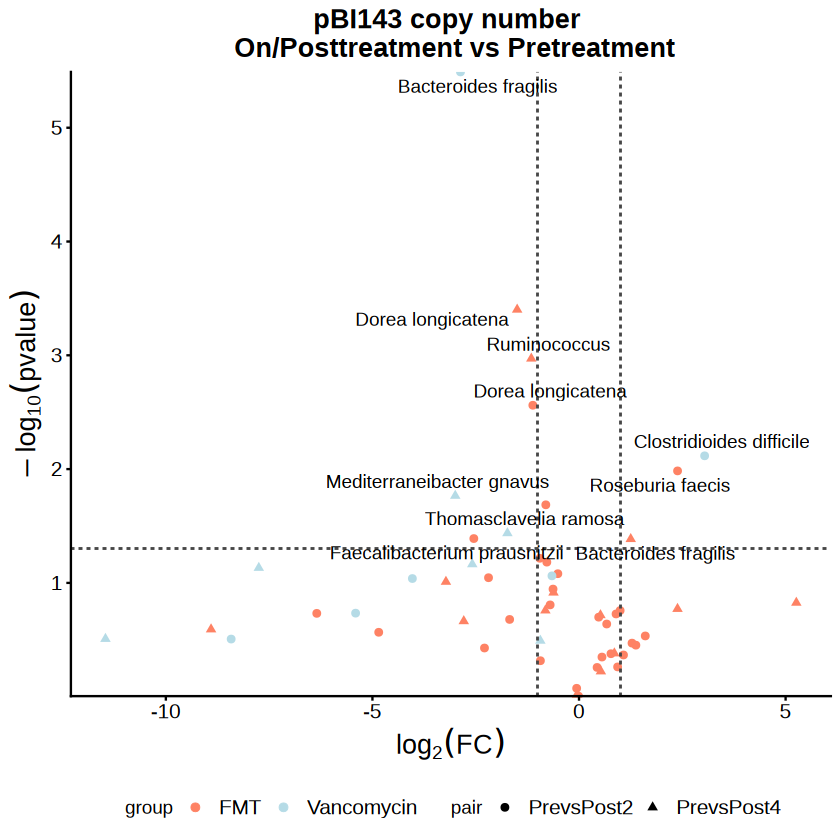

In [8]:
p1.4.1 = ggplot(pbidf.test, aes(x = logfoldchange, y = -log10(pvalue))) +
    geom_point(data = pbidf.test,aes(shape = pair,color = group), 
              size=2, stroke = 0.3)+
    #scale_fill_manual(values = colors)+
    scale_color_manual(values = samplecolors)+
    geom_hline(yintercept = -log10(0.05), color="#474747", linewidth = 0.6, linetype="dashed")+
    geom_vline(xintercept = c(-1,1), color="#474747", linewidth = 0.6, linetype="dashed")+
    geom_text_repel(data = pbidf.test[pbidf.test$change == "up" | pbidf.test$change == "down" ,],aes(x = logfoldchange, y = -log10(pvalue),label = species) ) +
    #scale_x_continuous(limits = c(-3, 3), breaks = seq(-3, 3, 1))+
    scale_y_continuous(expand = c(0, 0))+
    #scale_shape_manual(values = c(21, 24)) +
    labs(x = expression(log[2](FC)), y = expression(-log[10](pvalue)))+
    theme_classic()+
    theme(legend.position="bottom",
    legend.text=element_text(size = 12),
    plot.title = element_text(size = 16, face="bold",hjust = 0.5),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12)) + ggtitle("pBI143 copy number \n On/Posttreatment vs Pretreatment")
p1.4.1
# ggexport(p1.4.1,
#          filename = "../downstream_analysis/figures/f2.1_pBI143_copynumber_total_vocano__25_09_30.pdf",
#          width = 4,height = 5)

## Figure6d

In [241]:
#load reference 
library(readxl)
refdata <- read_excel("refdata/mmc7.xlsx",sheet = 3)
head(refdata)

metagenome_name,taxon,folder,coverage,n_rps,coverage_pbi143,cov_ratios
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AST0087,Bacteroides uniformis,/healthy,13.48124,6,221.22295,16.409693
AST0089,Bacteroides uniformis,/healthy,15.07924,6,22.27306,1.477068
AST0110,Bacteroides uniformis,/healthy,16.98523,5,191.54885,11.277378
AST0148,Parabacteroides merdae,/healthy,24.90084,7,614.65505,24.684108
AUS0002,Parabacteroides distasonis,/healthy,18.69600,8,534.83442,28.606887
AUS0016,Parabacteroides distasonis,/healthy,17.07426,17,64.92229,3.802349


In [245]:
length(unique(refdata$taxon))
mytaxton = unique(pbidf$species)
unique(refdata$taxon)
length(mytaxton[mytaxton %in% unique(refdata$taxon)])
cmptaxton = mytaxton[mytaxton %in% unique(refdata$taxon)]
cmptaxton

[1] 21

[1] "Bacteroides uniformis"        "Parabacteroides merdae"      
 [3] "Parabacteroides distasonis"   "Bacteroides fragilis"        
 [5] "Parabacteroides sp000436495"  "Bacteroides caccae"          
 [7] "Bacteroides stercoris"        "Bacteroides plebeius"        
 [9] "Bacteroides coprophilus"      "Bacteroides vulgatus"        
[11] "Parabacteroides goldsteinii"  "Bacteroides cellulosilyticus"
[13] "Parabacteroides johnsonii"    "Bacteroides ndongoniae"      
[15] "Bacteroides dorei"            "Bacteroides coprocola"       
[17] "Bacteroides togonis"          "Bacteroides pectinophilus"   
[19] "Parabacteroides gordonii"     "Bacteroides faecis"          
[21] "Parabacteroides sp900155425"

[1] 4

[1] "Bacteroides uniformis"       "Bacteroides fragilis"       
[3] "Parabacteroides distasonis"  "Parabacteroides goldsteinii"

In [272]:
cmptaxton = cmptaxton[1:3] #delet Parabacteroides goldsteinii, witch is too few
refdatahub = refdata[refdata$taxon %in% cmptaxton,]
refdatahub = refdatahub[,c("taxon","folder","cov_ratios")]
refdatahub$folder = substr(refdatahub$folder, 2, nchar(refdatahub$folder))
colnames(refdatahub) = c("species","condition","copy_number")
refdatahub$group = "reference"
pbidf.hub = pbidf[pbidf$species %in% cmptaxton,]
pbidf.hub = pbidf.hub[,c("species","condition","copy_number","group")]
cmpdf = rbind(pbidf.hub,refdatahub)
head(cmpdf)

,species,condition,copy_number,group
,<chr>,<chr>,<dbl>,<chr>
4,Bacteroides uniformis,1,0.1732167,Vancomycin
5,Bacteroides fragilis,1,16.5311262,Vancomycin
6,Bacteroides fragilis,1,0.6422204,Vancomycin
11,Bacteroides fragilis,1,0.7404305,Vancomycin
17,Bacteroides fragilis,1,25.2998160,Vancomycin
18,Bacteroides fragilis,1,157.2796579,Vancomycin


In [634]:
#try to calculate pBI143 total copynumber
#failed
pbidf.hub.sum = pbidf[pbidf$species %in% cmptaxton,]
head(pbidf.hub.sum)
mean(pbidf.hub.sum$genome_depth)
celldivdf.hub = celldivdf[celldivdf$species %in% cmptaxton,]
nrow(pbidf.hub.sum)
pbidf.hub.sum = merge(pbidf.hub.sum[,c("new_name","species","pBI143_depth","genome_depth","sample","condition","group")],
                     celldivdf.hub[,c("new_name","species","sample","condition","group")],
                      by = c("new_name","species","sample","condition","group"),all = T)
nrow(pbidf.hub.sum)
pbidf.hub.sum[is.na(pbidf.hub.sum$pBI143_depth),]$pBI143_depth = 0
pbidf.hub.sum[is.na(pbidf.hub.sum$genome_depth),]$genome_depth = 0.6
pbidf.hub.sum = pbidf.hub.sum %>% dplyr::group_by(species,sample,group,condition) %>% 
                            dplyr::summarise(pBI143_depth = sum(pBI143_depth),genome_depth = sum(genome_depth))
pbidf.hub.sum$copy_number = pbidf.hub.sum$pBI143_depth/pbidf.hub.sum$genome_depth
pbidf.hub.sum

,new_name,name.x,plas_reads_num,species,GCA,ANI,db,fastq_num,plas_ratio,name.y,pBI143_depth,genome_depth,group,copy_number,log,sample,condition
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
4,C282_1_lib1_out_AAACCTGACAGCGGTTAAGTCATTGCCGT,lib1_out_AAACCTGACAGCGGTTAAGTCATTGCCGT,1,Bacteroides uniformis,GCF_024760085.1,98.96,refseq,10180,0.009823183,lib1_out_AAACCTGACAGCGGTTAAGTCATTGCCGT,0.2034947,1.17479822,Vancomycin,0.1732167,-1.7532116,C282_1,1
5,C282_1_lib1_out_AAACCTGACAGGAATGAAGTCAATTACTC,lib1_out_AAACCTGACAGGAATGAAGTCAATTACTC,2,Bacteroides fragilis,GCF_000965785.1,99.50,refseq,1261,0.158604282,lib1_out_AAACCTGACAGGAATGAAGTCAATTACTC,0.5496906,0.03325185,Vancomycin,16.5311262,2.8052450,C282_1,1
6,C282_1_lib1_out_AAACCTGACAGGAATGAAGTCACGGAGTC,lib1_out_AAACCTGACAGGAATGAAGTCACGGAGTC,2,Bacteroides fragilis,GCF_000965785.1,99.59,refseq,7507,0.026641801,lib1_out_AAACCTGACAGGAATGAAGTCACGGAGTC,0.5016382,0.78109973,Vancomycin,0.6422204,-0.4428238,C282_1,1
11,C282_1_lib1_out_AAACCTGACAGTAAGAGAGTCACTGCGGA,lib1_out_AAACCTGACAGTAAGAGAGTCACTGCGGA,1,Bacteroides fragilis,GCF_000965785.1,99.76,refseq,2171,0.046061723,lib1_out_AAACCTGACAGTAAGAGAGTCACTGCGGA,0.1907535,0.25762519,Vancomycin,0.7404305,-0.3005235,C282_1,1
17,C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,144,Bacteroides fragilis,GCF_000965785.1,99.62,refseq,10517,1.369211752,lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,32.9293775,1.30156589,Vancomycin,25.2998160,3.2307971,C282_1,1
18,C282_1_lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,76,Bacteroides fragilis,GCF_000965785.1,99.83,refseq,1059,7.176581681,lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,13.5063706,0.08587487,Vancomycin,157.2796579,5.0580255,C282_1,1


[1] 0.6086832

[1] 7322

[1] 18329

`summarise()` has grouped output by 'species', 'sample', 'group'. You can
override using the `.groups` argument.


species,sample,group,condition,pBI143_depth,genome_depth,copy_number
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Bacteroides fragilis,C282_1,Vancomycin,1,109549.8376,1222.5343125,89.60880
Bacteroides fragilis,C282_1,Vancomycin,Pretreatment,0.0000,838.8000000,0.00000
Bacteroides fragilis,C282_2,Vancomycin,2,21246.3633,712.9426132,29.80094
Bacteroides fragilis,C282_2,Vancomycin,Ontreatment,0.0000,1033.2000000,0.00000
Bacteroides fragilis,C282_3,Vancomycin,3,910.9221,53.5400989,17.01383
Bacteroides fragilis,C282_3,Vancomycin,Posttreatment,0.0000,6.0000000,0.00000
Bacteroides fragilis,C295_1,FMT,1,7719.3888,272.5123890,28.32674
Bacteroides fragilis,C295_1,FMT,Pretreatment,0.0000,514.8000000,0.00000
Bacteroides fragilis,C295_2,FMT,2,6206.9443,211.0396009,29.41128


In [635]:
cmpdf$condition2 = cmpdf$condition
cmpdf[cmpdf$condition %in% c("3","healthy","2"),]$condition2 = "Healthy"
cmpdf[cmpdf$condition %in% c("1","IBD"),]$condition2 = "Disease"
cmpdf2 = cmpdf[cmpdf$condition2 %in% c("Healthy","Disease"),]
cmpdf2$group = factor(cmpdf2$group,levels = c("FMT","Vancomycin","reference"))
cmpdf2[cmpdf2$condition %in% "1",]$condition = "Pretreatment"
cmpdf2[cmpdf2$condition %in% c("3","2"),]$condition = "Posttreatment"
cmpdf2[cmpdf2$condition %in% "healthy",]$condition = "Healthy(ref)"
cmpdf2[cmpdf2$condition %in% "IBD",]$condition = "IBD(ref)"
cmpdf2$condition = factor(cmpdf2$condition,levels = c("Pretreatment","IBD(ref)","Posttreatment","Healthy(ref)"))

file saved to ../downstream_analysis/figures/f2.2_pBI143_copynumber_of_hubspecies_withref_25_06_17.pdf



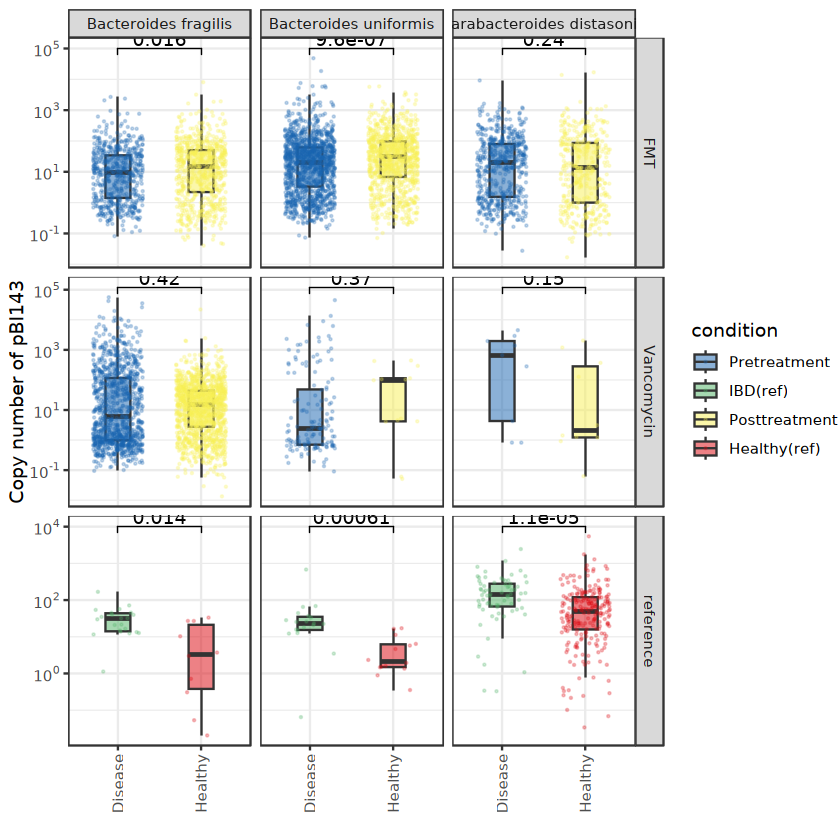

In [636]:
library(scales)
p1.3 = ggplot(cmpdf2,aes(x = condition2,y = copy_number)) +
   geom_boxplot(aes(fill = condition),width = 0.3,alpha = 0.5,outlier.colour = NA) + 
   geom_jitter(aes(color = condition),size = 0.2,alpha = 0.25,width = 0.3) +
   facet_grid(group~species,scales = "free") +
   scale_y_log10(
    labels = trans_format("log10", math_format(10^.x)) # 直接指定标签格式
   ) +
   scale_fill_discreterainbow() +
   scale_color_discreterainbow() +
   stat_compare_means(method = "t.test",comparisons = list(c("Disease","Healthy"))) + theme_bw() +
   theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("") + 
   ylab("Copy number of pBI143")
p1.3
ggexport(p1.3,
         filename = "../downstream_analysis/figures/f2.2_pBI143_copynumber_of_hubspecies_withref_25_06_17.pdf",
         width = 6.5,height = 4.5)

## Figure6f

In [13]:
pbidf.hub = pbidf[pbidf$plas_reads_num > 100,]
nrow(pbidf.hub)

[1] 2010

In [21]:
length(unique(pbidf$pBI143_version))

[1] 6

In [110]:
### Enrich score analysis
pbidf.st = pbidfv %>% group_by(pBI143_version,species,group,condition) %>% dplyr::summarise(cellnum_target = length(unique(name)))
pbidf.st = pbidf.st[pbidf.st$cellnum_target > 5,]
length(unique(pbidf.st$species))
#pbidf.st
#pbidf.st$pBI143_version = paste0("Version",pbidf.st$pBI143_version)
pbidf.st$pBI143_version = as.character(pbidf.st$pBI143_version)
head(pbidf.st)

`summarise()` has grouped output by 'pBI143_version', 'species', 'group'. You
can override using the `.groups` argument.


[1] 13

pBI143_version,species,group,condition,cellnum_target
<chr>,<chr>,<chr>,<chr>,<int>
Version1,Bacteroides fragilis,FMT,Ontreatment,143
Version1,Bacteroides fragilis,FMT,Posttreatment,134
Version1,Bacteroides fragilis,FMT,Pretreatment,177
Version1,Bacteroides fragilis,Vancomycin,Ontreatment,437
Version1,Bacteroides fragilis,Vancomycin,Posttreatment,9
Version1,Bacteroides fragilis,Vancomycin,Pretreatment,456


In [111]:
pbidf.st = merge(pbidf.st,celldivdf.st,by = c("species","group","condition"))
pbidf.st = merge(pbidf.st,pbidf.stt,by = c("pBI143_version","group","condition"))
pbidf.st

pBI143_version,group,condition,species,cellnum_target,cellnum_species,cellnum_pBI143
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
Version1,FMT,Ontreatment,Parabacteroides distasonis,90,539,545
Version1,FMT,Ontreatment,Parabacteroides goldsteinii,7,17,545
Version1,FMT,Ontreatment,Bacteroides uniformis,267,1092,545
Version1,FMT,Ontreatment,Parabacteroides sp.,16,91,545
Version1,FMT,Ontreatment,Bacteroides fragilis,143,643,545
Version1,FMT,Posttreatment,Bacteroides fragilis,134,781,279
Version1,FMT,Posttreatment,Bacteroides uniformis,93,612,279
Version1,FMT,Posttreatment,Parabacteroides distasonis,27,441,279
Version1,FMT,Posttreatment,Parabacteroides sp.,10,68,279


In [112]:

# 构建列联表
Enrichanalysis = function(a,b,c,d){
    data <- matrix(c(a, c, b, d), nrow = 2, 
               dimnames = list(
                 c("In_Category", "Not_In_Category"),
                 c("Target_Set", "Background_Set")
               ))

    # Fisher检验
    result <- fisher.test(data, alternative = "greater")
    p_value <- result$p.value
    odds_ratio <- result$estimate
    
    # 富集倍数
    fold_enrich <- (a / (a+b)) / (c / (c+d))
    
    # 输出结果
    res = c("Pvalue" = p_value, 
        "OddsRatio" = odds_ratio,
        "FoldEnrichment" = fold_enrich)
    return(res)
}

pbidf.st$Pvalue = 1
pbidf.st$OddsRatio = NA
pbidf.st$FoldEnrichment = NA
for(i in 1:nrow(pbidf.st)){
    pbidf.st.hub = pbidf.st[i,]
    N = nrow(anotdf[anotdf$group == pbidf.st[i,]$group & anotdf$condition == pbidf.st[i,]$condition,])
    a = pbidf.st.hub$cellnum_target
    b = pbidf.st.hub$cellnum_species - a
    c = pbidf.st.hub$cellnum_pBI143 - a
    d = N - (a + b + c)
    res = Enrichanalysis(a,b,c,d)
    pbidf.st$Pvalue[i] = res[1]
    pbidf.st$OddsRatio[i] = res[2]
    pbidf.st$FoldEnrichment[i] = res[3]
}
head(pbidf.st)

,pBI143_version,group,condition,species,cellnum_target,cellnum_species,cellnum_pBI143,Pvalue,OddsRatio,FoldEnrichment
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,Version1,FMT,Ontreatment,Parabacteroides distasonis,90,539,545,5.510686e-14,2.776508,2.480418
2,Version1,FMT,Ontreatment,Parabacteroides goldsteinii,7,17,545,1.250745e-04,8.767842,5.572600
3,Version1,FMT,Ontreatment,Bacteroides uniformis,267,1092,545,4.495747e-87,6.897132,5.458277
4,Version1,FMT,Ontreatment,Parabacteroides sp.,16,91,545,1.016176e-03,2.692488,2.395397
5,Version1,FMT,Ontreatment,Bacteroides fragilis,143,643,545,1.612914e-36,4.447207,3.681689
6,Version1,FMT,Posttreatment,Bacteroides fragilis,134,781,279,8.081743e-41,5.975763,5.124765


In [113]:
pbidf.st$ratio = pbidf.st$cellnum_target/pbidf.st$cellnum_species
pbidf.st[pbidf.st$species == "Bacteroides fragilis" & pbidf.st$group == "FMT",]

,pBI143_version,group,condition,species,cellnum_target,cellnum_species,cellnum_pBI143,Pvalue,OddsRatio,FoldEnrichment,ratio
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
5,Version1,FMT,Ontreatment,Bacteroides fragilis,143,643,545,1.612914e-36,4.447207,3.681689,0.222395023
6,Version1,FMT,Posttreatment,Bacteroides fragilis,134,781,279,8.081743e-41,5.975763,5.124765,0.171574904
14,Version1,FMT,Pretreatment,Bacteroides fragilis,177,858,912,4.464918e-41,3.957910,3.348133,0.206293706
31,Version2,FMT,Ontreatment,Bacteroides fragilis,49,643,180,2.282112e-13,4.107160,3.871345,0.076205288
35,Version2,FMT,Posttreatment,Bacteroides fragilis,29,781,67,3.125241e-08,4.355091,4.232057,0.037131882
38,Version2,FMT,Pretreatment,Bacteroides fragilis,59,858,282,2.098327e-15,3.875912,3.678442,0.068764569
49,Version3,FMT,Ontreatment,Bacteroides fragilis,17,643,59,7.675120e-06,4.274633,4.189254,0.026438569
51,Version3,FMT,Posttreatment,Bacteroides fragilis,7,781,13,1.394673e-03,6.515358,6.469697,0.008962868
54,Version3,FMT,Pretreatment,Bacteroides fragilis,24,858,133,7.456478e-06,3.120129,3.061269,0.027972028


In [121]:
nrow(pbidf.st)
pbidf.st$padj = p.adjust(pbidf.st$Pvalue)
nrow(pbidf.st[pbidf.st$padj < 0.05,])
pbidf.st$FoldEnrichment2 = pbidf.st$FoldEnrichment
pbidf.st[pbidf.st$FoldEnrichment > 10,]$FoldEnrichment2 = 10

[1] 76

[1] 51

file saved to ../downstream_analysis/figures/f3.3_pBI143_myversion_enrichscore_heatmap_25_10_06.pdf



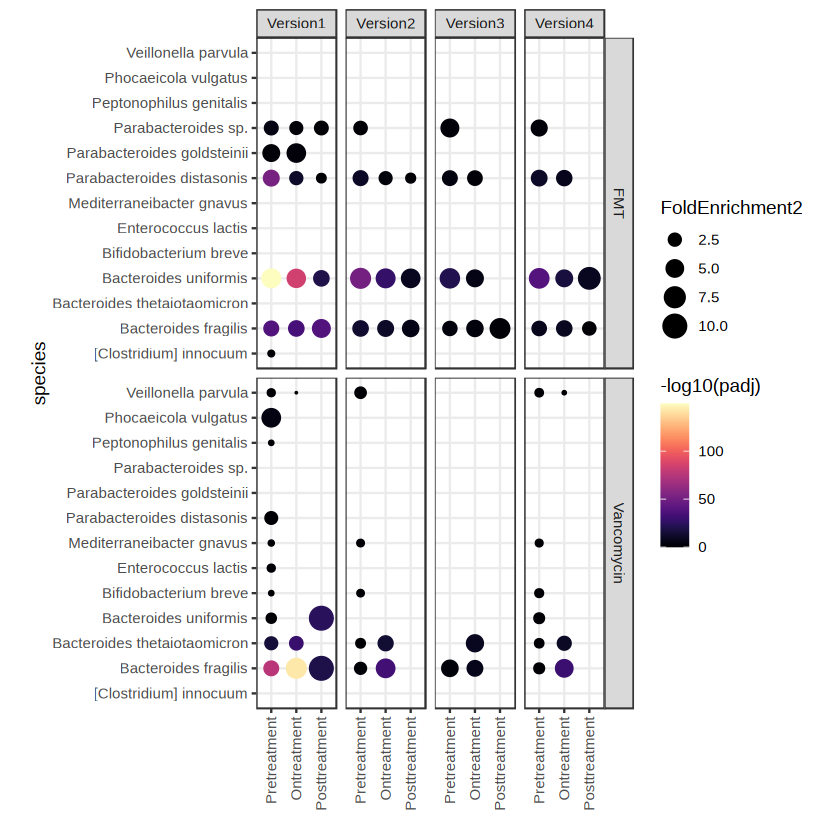

In [122]:
pbidf.st$condition = factor(pbidf.st$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p3.3 = ggplot(pbidf.st) + 
      geom_point(aes(x = condition,y = species,size = FoldEnrichment2,color = -log10(padj))) + 
      facet_grid(group~pBI143_version) +
      scale_color_viridis(option = "A") +
      scale_size_continuous(range = c(0.01,6)) +
    #scale_size_continuous(range = c(1, 5),limits = c(NA, max(pbidf.st$FoldEnrichment))) +
      #scale_color_gradient2(low = "#A8F1FF",high = "#E55050",mid = "#FFDCDC",midpoint = 2) +
      coord_fixed() + theme_bw() + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("")
p3.3
ggexport(p3.3, 
         filename = "../downstream_analysis/figures/f3.3_pBI143_myversion_enrichscore_heatmap_25_10_06.pdf",
         width = 7,height = 6)

In [629]:
##try bulk pBI143 distribution
#pbidft = merge(pbidf,pbidfv[,c("new_name","pBI143_version")],by = "new_name")
head(pbidft)
psbkdf = pbidft %>% group_by(group,condition) %>% dplyr::mutate(pB_countt = sum(plas_reads_num)) %>% 
                group_by(group,condition,pBI143_version) %>% dplyr::summarise(pB_count = sum(plas_reads_num),pB_ratio = pB_count/pB_countt[1])
psbkdf = psbkdf[order(psbkdf$group,psbkdf$condition,-psbkdf$pB_ratio),]
psbkdf

,new_name,name.x,plas_reads_num,species,GCA,ANI,db,fastq_num,plas_ratio,name.y,pBI143_depth,genome_depth,group,copy_number,log,sample,condition,pBI143_version
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>
1,C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,83,Bacteroides thetaiotaomicron,GCF_024758825.1,99.49,refseq,3842,2.16033316,lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,14.336731,0.20616649,Vancomycin,69.5395806,4.2418961,C282_1,1,1
2,C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,144,Bacteroides fragilis,GCF_000965785.1,99.62,refseq,10517,1.36921175,lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,32.929378,1.30156589,Vancomycin,25.2998160,3.2307971,C282_1,1,1
3,C282_1_lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,76,Bacteroides fragilis,GCF_000965785.1,99.83,refseq,1059,7.17658168,lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,13.506371,0.08587487,Vancomycin,157.2796579,5.0580255,C282_1,1,2
4,C282_1_lib1_out_AACCGCGACAGAACTCAGGTCAGACCTGG,lib1_out_AACCGCGACAGAACTCAGGTCAGACCTGG,269,Bacteroides fragilis,GCF_000965785.1,99.51,refseq,9665,2.78323849,lib1_out_AACCGCGACAGAACTCAGGTCAGACCTGG,47.470695,0.78387470,Vancomycin,60.5590352,4.1036187,C282_1,1,1
5,C282_1_lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,5,Bacteroides uniformis,GCF_024760085.1,98.12,refseq,22534,0.02218869,lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,2.029487,3.07910136,Vancomycin,0.6591166,-0.4168549,C282_1,1,3
6,C282_1_lib1_out_AACCGCGACAGCGTGTCTGTCAATTTCTG,lib1_out_AACCGCGACAGCGTGTCTGTCAATTTCTG,934,Bacteroides thetaiotaomicron,GCF_024799845.1,98.70,refseq,18792,4.97020009,lib1_out_AACCGCGACAGCGTGTCTGTCAATTTCTG,213.239898,1.73776725,Vancomycin,122.7091248,4.8098167,C282_1,1,4


`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.


group,condition,pBI143_version,pB_count,pB_ratio
<chr>,<chr>,<int>,<int>,<dbl>
FMT,1,4,119800,5.739995e-01
FMT,1,1,40027,1.917819e-01
FMT,1,2,35468,1.699383e-01
FMT,1,3,7141,3.421478e-02
FMT,1,5,6132,2.938034e-02
FMT,1,6,143,6.851579e-04
FMT,2,4,53541,4.932699e-01
FMT,2,1,24500,2.257170e-01
FMT,2,2,16539,1.523728e-01


Warning message in geom_point(aes(group = species), size = 1.5, shape = 21, alpha = 0.5, :
"Ignoring unknown parameters: `stroke.size`"


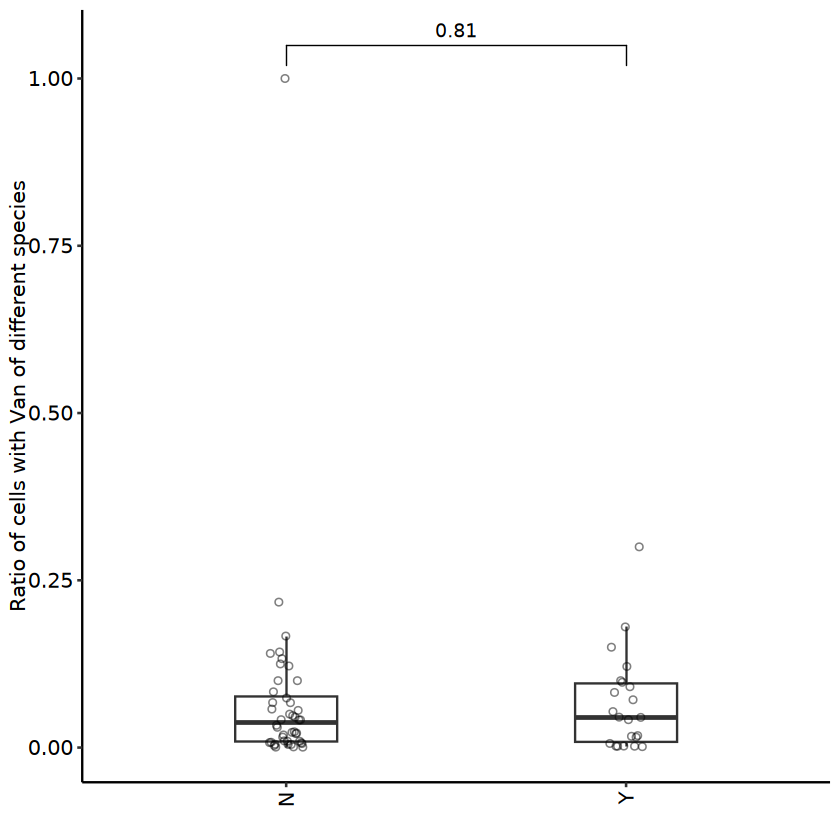

In [105]:
#compare pBI143 effect
cidpbi = celldivdf[celldivdf$new_name %in% pbidf$new_name,]
cidnpbi = celldivdf[!celldivdf$new_name %in% pbidf$new_name,]

vrdf.st.spc = vrdf[vrdf$new_name %in% cidpbi$new_name,] %>% group_by(species) %>% 
        dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = cidpbi %>% group_by(species) %>% dplyr::summarise(cellnt = length(unique(new_name)))
vrdf.st.spcy = merge(vrdf.st.spc,cell.st.spc,by = c("species"))
vrdf.st.spcy$prop = vrdf.st.spcy$celln/vrdf.st.spcy$cellnt

vrdf.st.spc = vrdf[!vrdf$new_name %in% cidpbi$new_name,] %>% group_by(species) %>% 
        dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = cidnpbi %>% group_by(species) %>% dplyr::summarise(cellnt = length(unique(new_name)))
vrdf.st.spcn = merge(vrdf.st.spc,cell.st.spc,by = c("species"))
vrdf.st.spcn$prop = vrdf.st.spcn$celln/vrdf.st.spcn$cellnt

vrdf.st.spcy$pbi143 = "Y"
vrdf.st.spcn$pbi143 = "N"
vrdf.st.spc = rbind(vrdf.st.spcy,vrdf.st.spcn)

my_comparisons = list(c("Y","N"))
p5.2 = ggplot(vrdf.st.spc,aes(x = pbi143,y = prop)) + 
    geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA) +
    #geom_line(aes(group = species,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    geom_point(aes(group = species),size = 1.5,shape = 21,alpha = 0.5,
               stroke.size = 0.5,position = position_dodge(0.1)) +
    scale_fill_npg() +
    scale_color_manual(values = c("black","red")) +
    # scale_fill_manual(values=c("#993365","#666632"))+
    # scale_color_manual(values=c("#993365","#666632"))+
    # scale_fill_brewer(palette='Set3') +
    # scale_color_brewer(palette='Set3') +
    stat_compare_means(paired = F,method = "t.test",comparisons = my_comparisons) + 
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with Van of different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.2

In [9]:
head(vrdf)

,name,contig,start,end,gene,cov_map,gaps,cov_percent,identity,database,accession,species,GCA,ANI,db,new_name,num,group,condition
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1085,2227,vanS-Cd,1-1143/1143,0/0,100.00,99.738,ncbi,NG_061619.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
2,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,2217,2918,vanR-Cd,1-702/702,0/0,100.00,100.000,ncbi,NG_061618.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
3,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1,824,vanG-Cd,1-863/1101,1/39,74.84,95.133,ncbi,NG_061616.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
4,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,650,1094,vanR-Cd,251-702/702,6/9,63.25,96.247,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin,Pretreatment
5,lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,utg000050l,754,1194,vanR-Cd,258-702/702,3/4,62.82,97.753,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_009831375.1,99.41,refseq,C282_1_lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,1,Vancomycin,Pretreatment
6,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,96,660,vanS-Cd,1-567/1143,5/6,49.26,97.188,ncbi,NG_061619.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin,Pretreatment


In [8]:
vrdf

,name,contig,start,end,gene,cov_map,gaps,cov_percent,identity,database,accession,species,GCA,ANI,db,new_name,num,group,condition
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1085,2227,vanS-Cd,1-1143/1143,0/0,100.00,99.738,ncbi,NG_061619.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
2,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,2217,2918,vanR-Cd,1-702/702,0/0,100.00,100.000,ncbi,NG_061618.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
3,lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,utg000248l,1,824,vanG-Cd,1-863/1101,1/39,74.84,95.133,ncbi,NG_061616.1,Clostridioides difficile,GCF_034273595.1,98.75,refseq,C282_1_lib2_out_ACCAGTAACAGAAATCCAGTCAGAACCTA,1,Vancomycin,Pretreatment
4,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,650,1094,vanR-Cd,251-702/702,6/9,63.25,96.247,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin,Pretreatment
5,lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,utg000050l,754,1194,vanR-Cd,258-702/702,3/4,62.82,97.753,ncbi,NG_061618.1,Mediterraneibacter gnavus,GCF_009831375.1,99.41,refseq,C282_1_lib1_out_CGCTTCAACAGGCGCGATGTCATCCACAC,1,Vancomycin,Pretreatment
6,lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,utg000142l,96,660,vanS-Cd,1-567/1143,5/6,49.26,97.188,ncbi,NG_061619.1,Mediterraneibacter gnavus,GCF_016904015.1,99.03,refseq,C282_1_lib1_out_TGTGTTTACAGGTAACTGGTCACATTCGC,1,Vancomycin,Pretreatment


##### Virus distribution

In [16]:
filename = list.files("crAssphage")
filename
samplename = substr(filename,1,6)
samplename

[1] "C282_1_crAssphage.txt" "C282_2_crAssphage.txt" "C295_1_crAssphage.txt"
[4] "C295_2_crAssphage.txt" "C295_3_crAssphage.txt"

[1] "C282_1" "C282_2" "C295_1" "C295_2" "C295_3"

In [18]:
virdf = NULL
for(i in 1:length(filename)){
    virdfi = read.delim(paste0("crAssphage/",filename[i]),sep = "\"")
    mycol = c("name","ref","count")
    virdfi = virdfi[,mycol]
    colnames(virdfi) = c("name","ref","species")
    virdfi$sample = samplename[i]
    virdf = rbind(virdf,virdfi)
}
head(virdf)
virdf$new_name = paste0(virdf$sample,"_",virdf$name)
nrow(virdf)
write.csv(virdf,file = "all_crAssphage_total.csv",row.names = F,quote = F)

,name,ref,species,sample
,<chr>,<chr>,<chr>,<chr>
1,lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,GCF_015161205.1_ASM1516120v1,Bacteroides uniformis,C282_1
2,lib1_out_AACCGCGACAGACGCAGAGTCAAGAATCT,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1
3,lib1_out_AAGACCTACAGAACTCAGGTCATCGTAGA,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1
4,lib1_out_AAGGTTCACAGACTGAACGTCATCGAGGC,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1
5,lib1_out_ACCGTAAACAGTTGACTCGTCAGTGCTTC,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1
6,lib1_out_ACGATACACAGCATATCGGTCAACTACCT,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1


[1] 581

In [20]:
virdf = read.csv("all_crAssphage_total.csv")

In [21]:
length(unique(virdf$species))

[1] 32

In [22]:
virdf$group = MySplit(virdf$new_name,"_",1)
virdf$condition = MySplit(virdf$new_name,"_",2)
virdf[virdf$group == "C282",]$group = "Vancomycin"
virdf[virdf$group == "C295",]$group = "FMT"
virdf[virdf$condition == "1",]$condition = "Pretreatment"
virdf[virdf$condition == "2",]$condition = "Ontreatment"
virdf[virdf$condition == "3",]$condition = "Posttreatment"
head(virdf)

,name,ref,species,sample,new_name,group,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,GCF_015161205.1_ASM1516120v1,Bacteroides uniformis,C282_1,C282_1_lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,Vancomycin,Pretreatment
2,lib1_out_AACCGCGACAGACGCAGAGTCAAGAATCT,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1,C282_1_lib1_out_AACCGCGACAGACGCAGAGTCAAGAATCT,Vancomycin,Pretreatment
3,lib1_out_AAGACCTACAGAACTCAGGTCATCGTAGA,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1,C282_1_lib1_out_AAGACCTACAGAACTCAGGTCATCGTAGA,Vancomycin,Pretreatment
4,lib1_out_AAGGTTCACAGACTGAACGTCATCGAGGC,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1,C282_1_lib1_out_AAGGTTCACAGACTGAACGTCATCGAGGC,Vancomycin,Pretreatment
5,lib1_out_ACCGTAAACAGTTGACTCGTCAGTGCTTC,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1,C282_1_lib1_out_ACCGTAAACAGTTGACTCGTCAGTGCTTC,Vancomycin,Pretreatment
6,lib1_out_ACGATACACAGCATATCGGTCAACTACCT,GCF_015161205.1_ASM1516120v1,Bacteroides fragilis,C282_1,C282_1_lib1_out_ACGATACACAGCATATCGGTCAACTACCT,Vancomycin,Pretreatment


file saved to ../downstream_analysis/figures/crAssphage_distribution_total_25_07_03.pdf



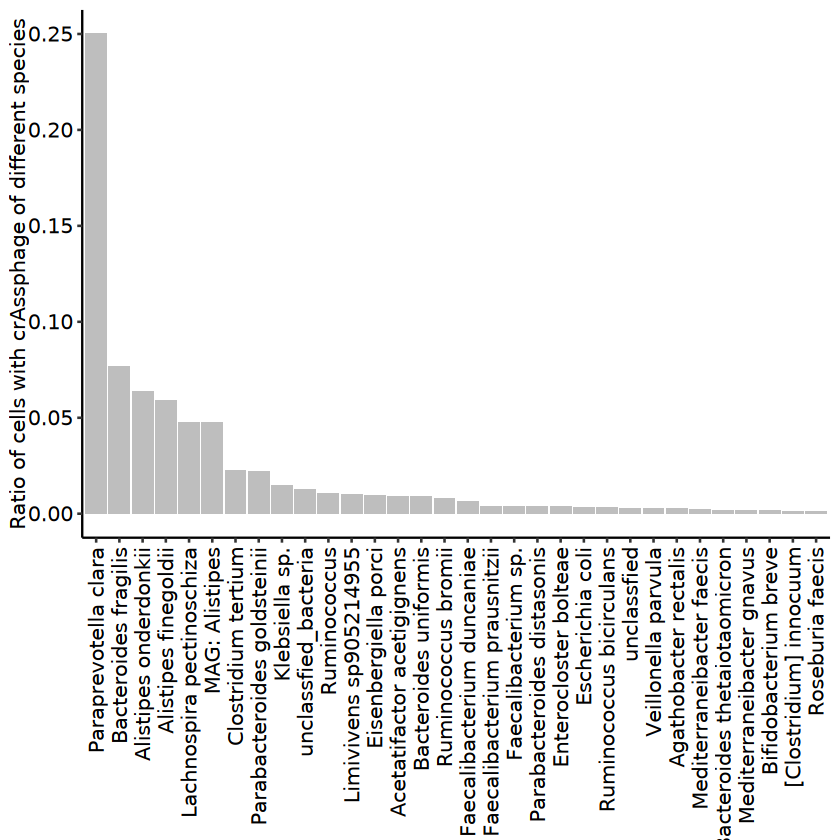

In [23]:
vrdf.st.spc = virdf %>% group_by(species) %>% dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = celldivdf %>% group_by(species) %>% dplyr::summarise(cellnt = length(unique(new_name)))
vrdf.st.spc = merge(vrdf.st.spc,cell.st.spc,by = c("species"))
vrdf.st.spc$prop = vrdf.st.spc$celln/vrdf.st.spc$cellnt
vrdf.st.spc = vrdf.st.spc[order(-vrdf.st.spc$prop),]
#vrdf.st.spc = vrdf.st.spc[vrdf.st.spc$cellnt > 10,]
vrdf.st.spc$species = factor(vrdf.st.spc$species,levels = unique(vrdf.st.spc$species))
p5.0 = ggplot(vrdf.st.spc,aes(x = species,y = prop)) + 
    geom_bar(stat = "identity",fill = "grey") +
    scale_fill_npg() +
    scale_color_npg() +
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with crAssphage of different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.0
ggexport(p5.0,filename = "../downstream_analysis/figures/crAssphage_distribution_total_25_07_03.pdf",width = 6,height = 5)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


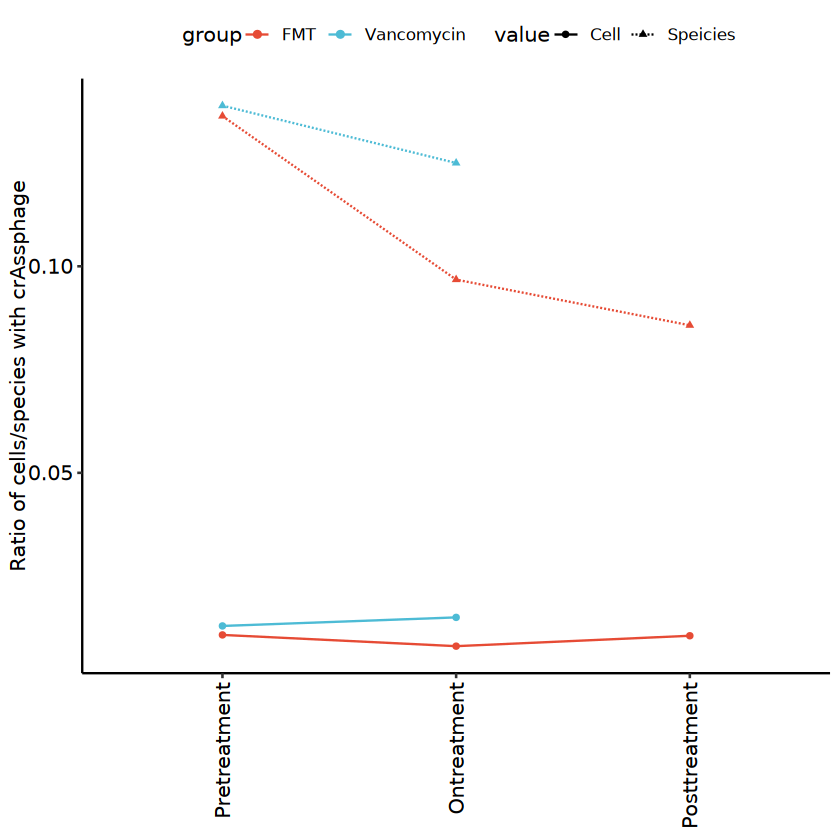

In [196]:
### virus ratio in different stage
sample.stc = celldivdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(new_name)))
pbidf.stc = virdf %>% dplyr::group_by(group,condition) %>% 
                    dplyr::summarise(count = length(unique(new_name)))
pbidf.stc = merge(pbidf.stc,sample.stc,by = c("group","condition"))
pbidf.stc$ratio = pbidf.stc$count/pbidf.stc$countt
pbidf.stc$value = "Cell"
#pbidf.stc
sample.sts = celldivdf %>% dplyr::group_by(group,condition) %>% 
            dplyr::summarise(countt = length(unique(species)))
pbidf.sts = virdf %>% dplyr::group_by(group,condition) %>% 
                    dplyr::summarise(count = length(unique(species)))
pbidf.sts = merge(pbidf.sts,sample.sts,by = c("group","condition"))
pbidf.sts$ratio = pbidf.sts$count/pbidf.sts$countt
pbidf.sts$value = "Speicies"
#pbidf.sts
virdf.st.smp = rbind(pbidf.sts,pbidf.stc)
virdf.st.smp$group2 = paste0(virdf.st.smp$group,"_",virdf.st.smp$value)
virdf.st.smp$condition = factor(virdf.st.smp$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
p5.1 = ggplot(virdf.st.smp, aes(x = condition, y = ratio)) +
  geom_line(aes(color = group, group = group2, linetype = value))+
  geom_point(aes(color = group, group = group2, shape = value)) +
  scale_fill_npg() +
  scale_color_npg() +
  xlab("") + ylab("Ratio of cells/species with crAssphage") + theme_pubr() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.1

`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.


[1] 57

[1] 56

Warning message in geom_point(aes(group = species, fill = group), size = 1.5, shape = 21, :
"Ignoring unknown parameters: `stroke.size`"


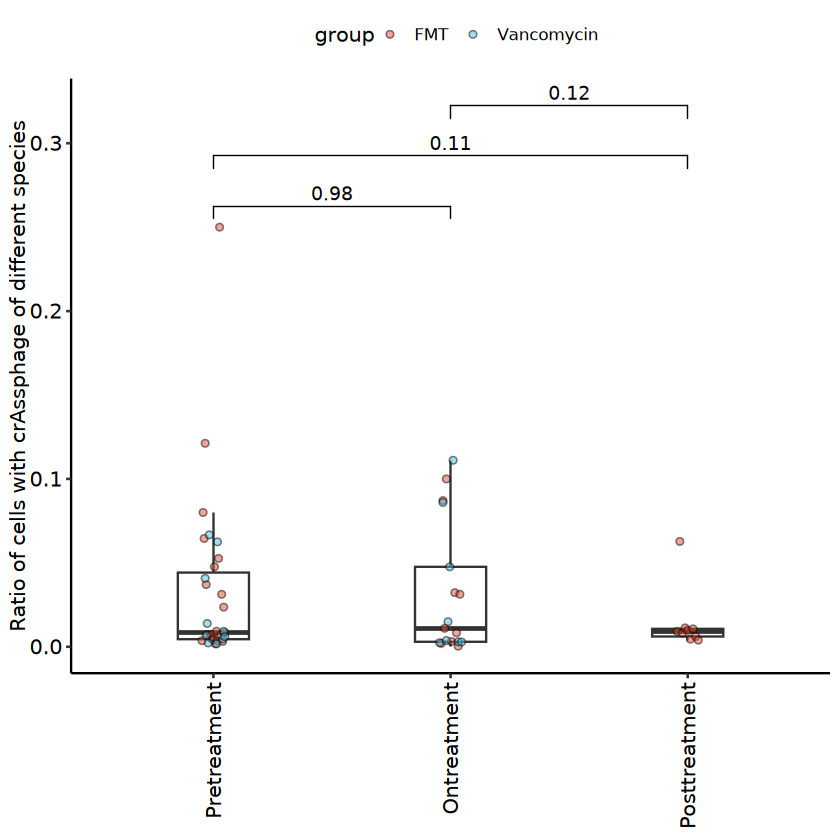

In [197]:
vrdf.st.spc = virdf %>% group_by(group,condition,species) %>% dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = celldivdf %>% group_by(group,condition,species) %>% dplyr::summarise(cellnt = length(unique(new_name)))
vrdf.st.spc = merge(vrdf.st.spc,cell.st.spc,by = c("group","condition","species"))
vrdf.st.spc$prop = vrdf.st.spc$celln/vrdf.st.spc$cellnt
nrow(vrdf.st.spc)
nrow(vrdf.st.spc[vrdf.st.spc$cellnt > 5,])
vrdf.st.spc$condition = factor(vrdf.st.spc$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))
my_comparisons = list(c("Pretreatment","Ontreatment"),c("Pretreatment","Posttreatment"),c("Ontreatment","Posttreatment"))

p5.2 = ggplot(vrdf.st.spc[vrdf.st.spc$cellnt > 1,],aes(x = condition,y = prop)) + 
    geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA) +
    #geom_line(aes(group = species,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    geom_point(aes(group = species,fill = group),size = 1.5,shape = 21,alpha = 0.5,stroke.size = 0.5,position = position_dodge(0.1)) +
    scale_fill_npg() +
    scale_color_npg() +
    # scale_fill_manual(values=c("#993365","#666632"))+
    # scale_color_manual(values=c("#993365","#666632"))+
    # scale_fill_brewer(palette='Set3') +
    # scale_color_brewer(palette='Set3') +
    stat_compare_means(paired = F,method = "t.test",comparisons = my_comparisons) + 
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with crAssphage of different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p5.2
# ggexport(p5.2,filename = "../downstream_analysis/figures/f5.1_crAssphage_cellratio_06_23.pdf",width = 3,height = 4)